# eDNA Metabarcoding Pipeline Analysis: Lake Geneva Soil
### isONclust3 Clustering Pipeline (Q15 Filter)
**Databases:** PR2 (JEDI) + MIDORI2 (COI)

**Project:** Genorobotics Semester Project (EPFL)  
**Dataset:** Soil eDNA from around Lake Geneva  
**Pipeline:** ONT metabarcoding with isONclust3 + SPOA consensus  
**Run date:** May 29, 2026

In [1]:
from scripts.notebook_utils import *
from pathlib import Path

setup_style()

BASE = Path('out/Soil_eDNA_JEDI_COI_14_01_26')
MARKERS = ['JEDI', 'COI']

In [2]:
# Load taxonomy data
df_jedi_raw = pd.read_csv(BASE / 'taxonomy_summary/JEDI/pr2/comprehensive_taxonomy_JEDI.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/COI/midori2/comprehensive_taxonomy_COI.csv')

prefix_jedi = get_tax_prefix(df_jedi_raw)
prefix_coi = get_tax_prefix(df_coi_raw)

print_data_summary(df_jedi_raw, 'JEDI', prefix_jedi)
print_data_summary(df_coi_raw, 'COI', prefix_coi)
display(df_jedi_raw.head(3))
display(df_coi_raw.head(3))


  JEDI (PR2 database)  -  803 OTUs x 40 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank', 'Sample_unclassified']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_barcode16', 'Sample_barcode17', 'Sample_barcode18', 'Sample_barcode19', 'Sample_barcode20', 'Sample_barcode21', 'Sample_barcode22', 'Sample_barcode23', 'Sample_barcode24']
Taxonomy columns:  ['PR2_Domain', 'PR2_Domain_Conf', 'PR2_Phylum', 'PR2_Phylum_Conf', 'PR2_Class', 'PR2_Class_Conf', 'PR2_Order', 'PR2_Order_Conf', 'PR2_Family', 'PR2_Family_Conf', 'PR2_Genus', 'PR2_Genus_Conf', 'PR2_Species', 'PR2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

  COI (MIDORI2 database)  -  1503 OTUs x 40 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank', 'Sample_unclassified']
Sample columns:    ['Sample_barcode01', 'S

,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,PR2_Order_Conf,PR2_Family,PR2_Family_Conf,PR2_Genus,PR2_Genus_Conf,PR2_Species,PR2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_JEDI_000546,7.082627,1,0.0,0.0,0.0,0.0,0.0,0.518459,0.563733,...,0.27,Arenicellaceae,0.06,HTCC5015,0.05,HTCC5015,0.05,Uncultured bacterium clone,88.2,8.410000e-144
1,OTU_JEDI_000864,1.597289,2,0.0,0.0,0.0,0.0,0.0,0.207063,0.038129,...,1.00,Burkholderiaceae,0.97,Acidovorax,0.24,Acidovorax,0.24,Uncultured bacterium partial,97.9,0.000000e+00
2,OTU_JEDI_000183,0.389917,3,0.0,0.0,0.0,0.0,0.0,0.006688,0.055198,...,1.00,Beijerinckiaceae,0.56,Beijerinckiaceae,0.26,Beijerinckiaceae_X,0.26,Uncultured bacterium partial,97.3,0.000000e+00


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,MIDORI2_Order_Conf,MIDORI2_Family,MIDORI2_Family_Conf,MIDORI2_Genus,MIDORI2_Genus_Conf,MIDORI2_Species,MIDORI2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000001,1.488314,1,0.449269,0.004559,0.295474,0.001959,0.478695,0.0,0.0,...,0.08,Naviculaceae,0.04,Navicula,0.02,Navicula,0.02,"Surirella sp. mitochondrion,",84.9,0.0
1,OTU_COI_001295,0.355887,2,0.000000,0.012158,0.000000,0.142417,0.000000,0.0,0.0,...,0.09,Simuliidae,0.02,Simulium,0.02,Simulium,0.02,Entomobrya nivalis voucher,82.9,0.0
2,OTU_COI_000311,0.280441,3,0.072222,0.001520,0.072506,0.000000,0.071995,0.0,0.0,...,0.21,Peronosporaceae,0.21,Phytophthora,0.15,Phytophthora,0.15,Phytophthora brevifila isolate,80.7,0.0


## 0. Pipeline Overview & Key Changes

**Pipeline steps:**
1. Preprocessing (quality filter Q>=15, length filter)
2. Marker classification (minimap2)
2b. Primer trimming (cutadapt)
3. Clustering (isONclust3 + SPOA consensus)
3b. Chimera removal (VSEARCH uchime_denovo)
4. Abundance matrix generation
5. Taxonomy assignment (VSEARCH SINTAX, confidence >= 0.8)
6. BLAST validation (top OTUs vs NCBI)
7. Comprehensive summary

### Results (May 29, 2026)
| Marker | Raw Clusters | Chimeras | Clean OTUs |
|--------|:---:|:---:|:---:|
| JEDI | 902 | 99 (11.0%) | **803** |
| COI | 1,670 | 167 (10.0%) | **1,503** |

- 24 barcodes: ~19 JEDI + ~5 COI
- Total reads: 108,945 → 77,816 kept (28.6% discarded — degraded soil DNA)
- Higher discard rate than water reflects soil DNA quality challenges

## Confidence Distribution Dashboard

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


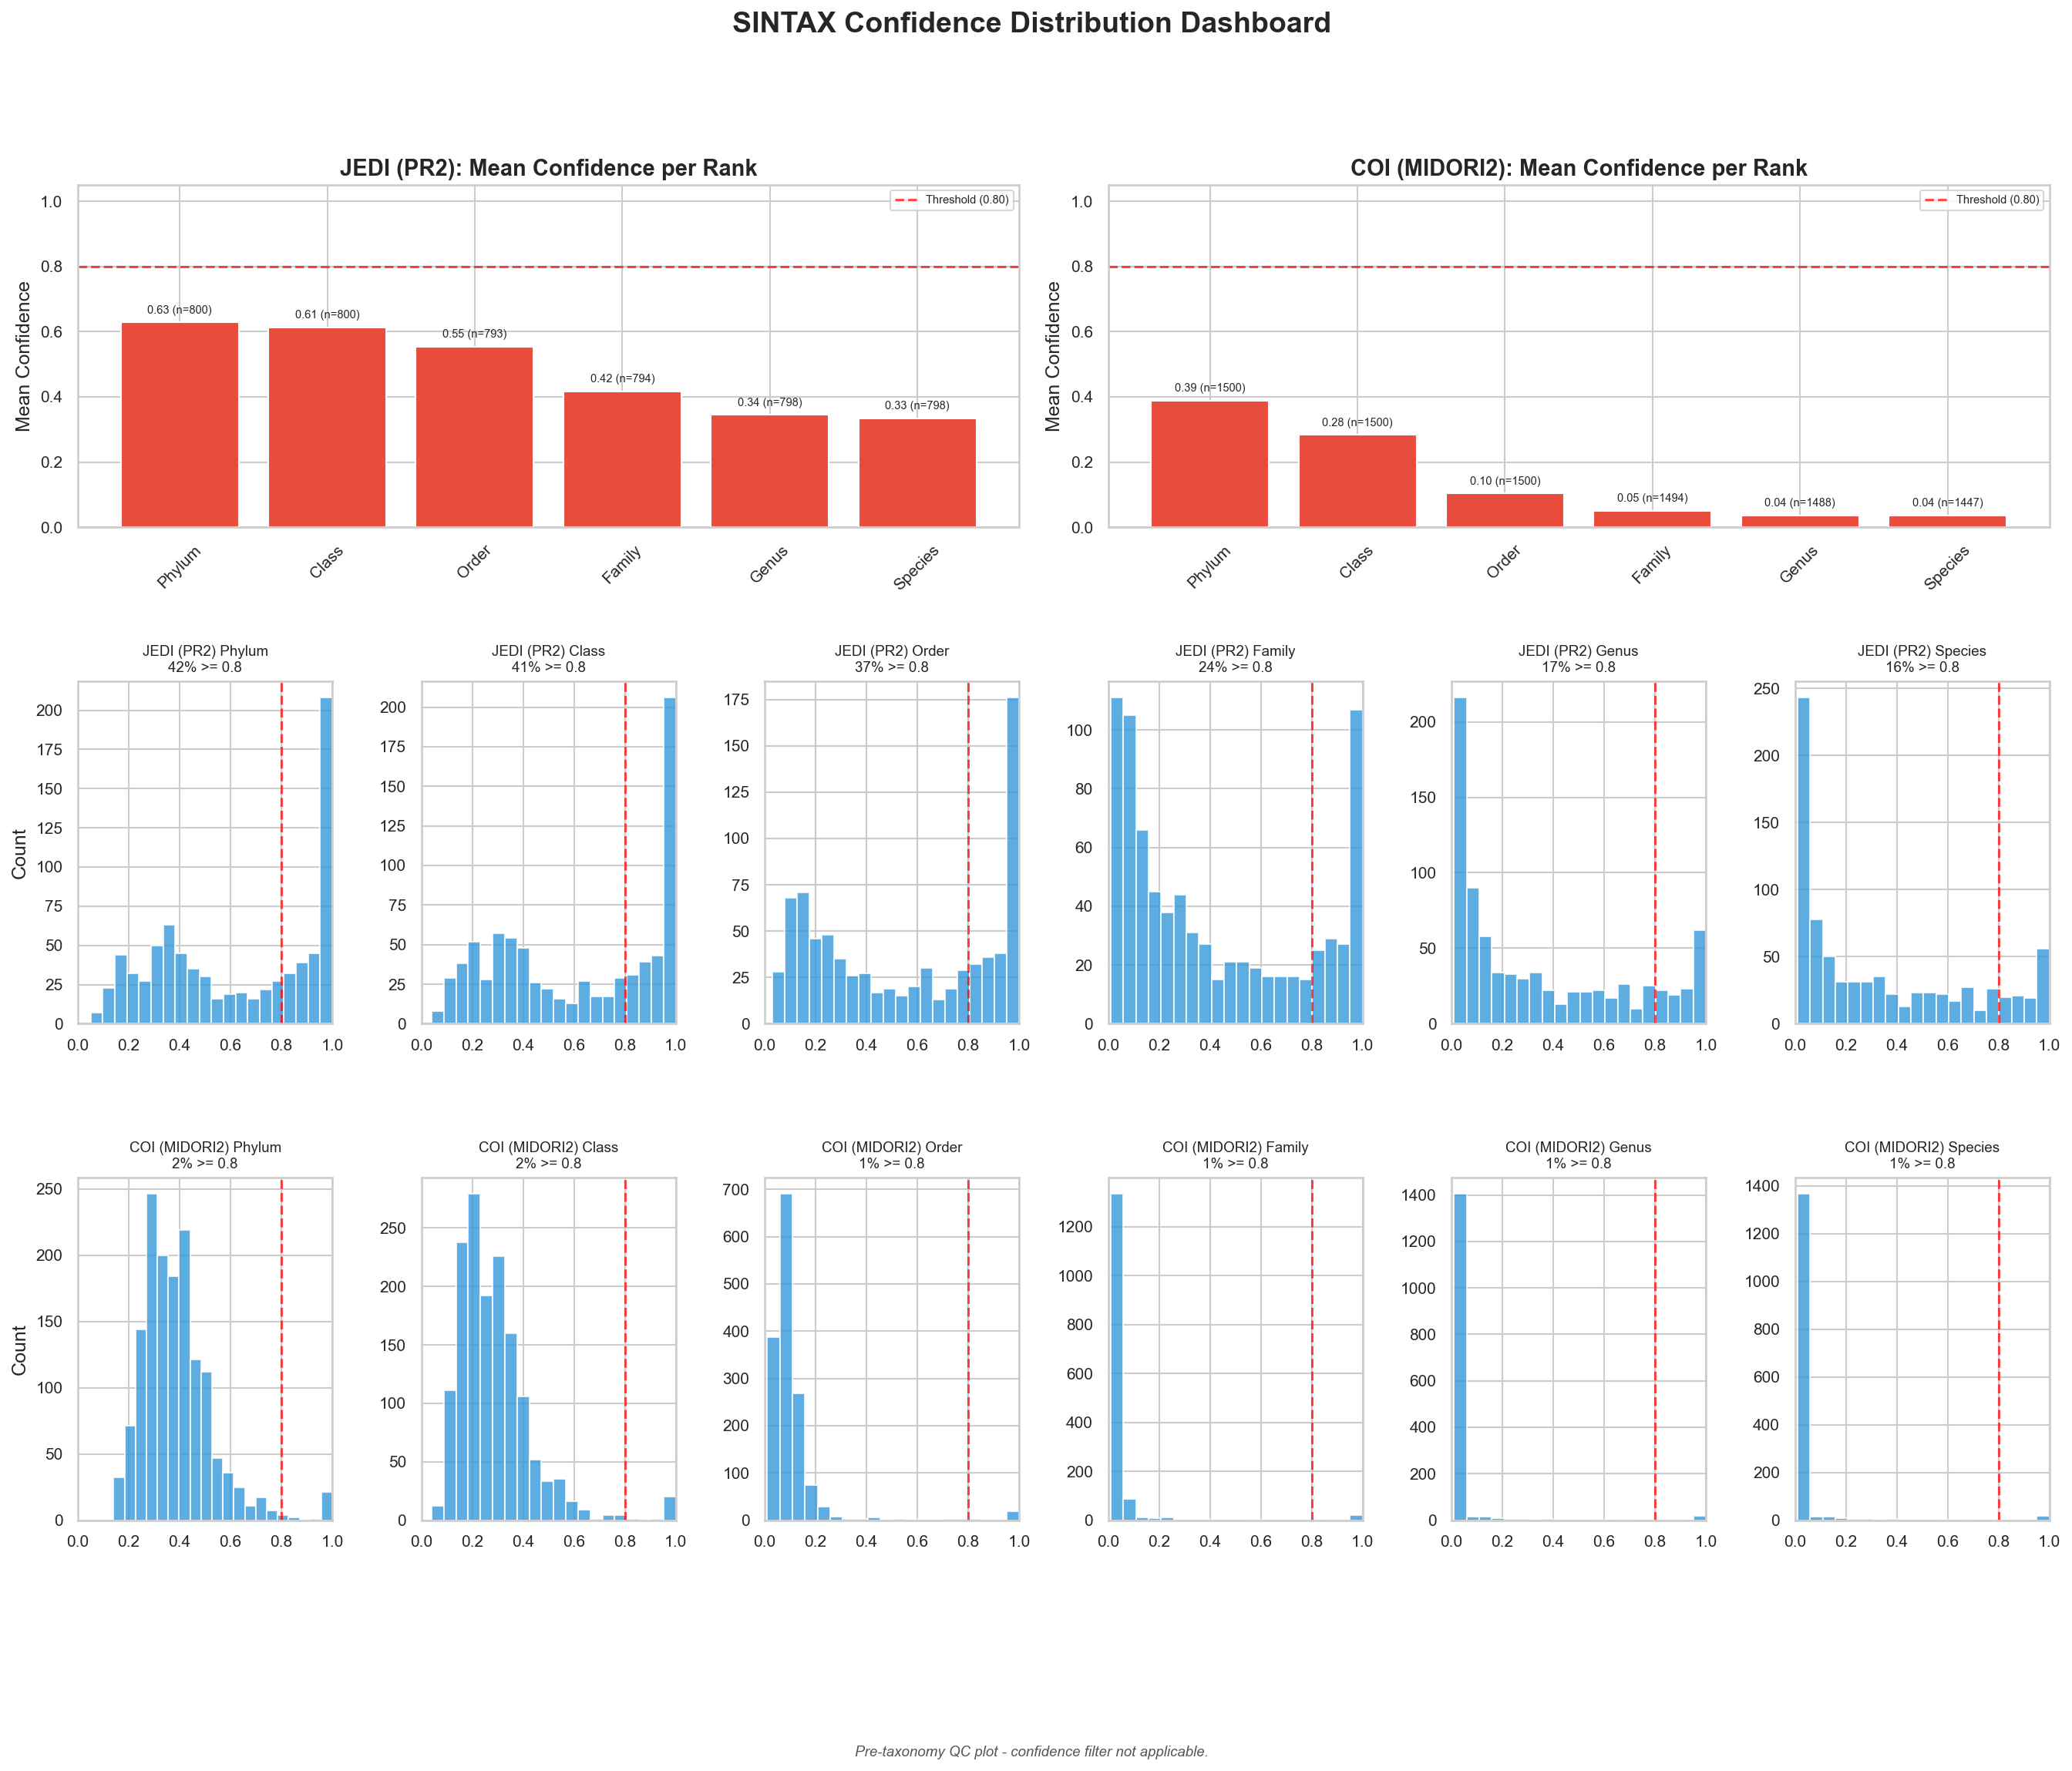

In [3]:
confidence_dashboard([
    (df_jedi_raw, prefix_jedi, f'JEDI ({prefix_jedi})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Database Performance Dashboard
Assignment rates and resolution depth for each marker with current database.

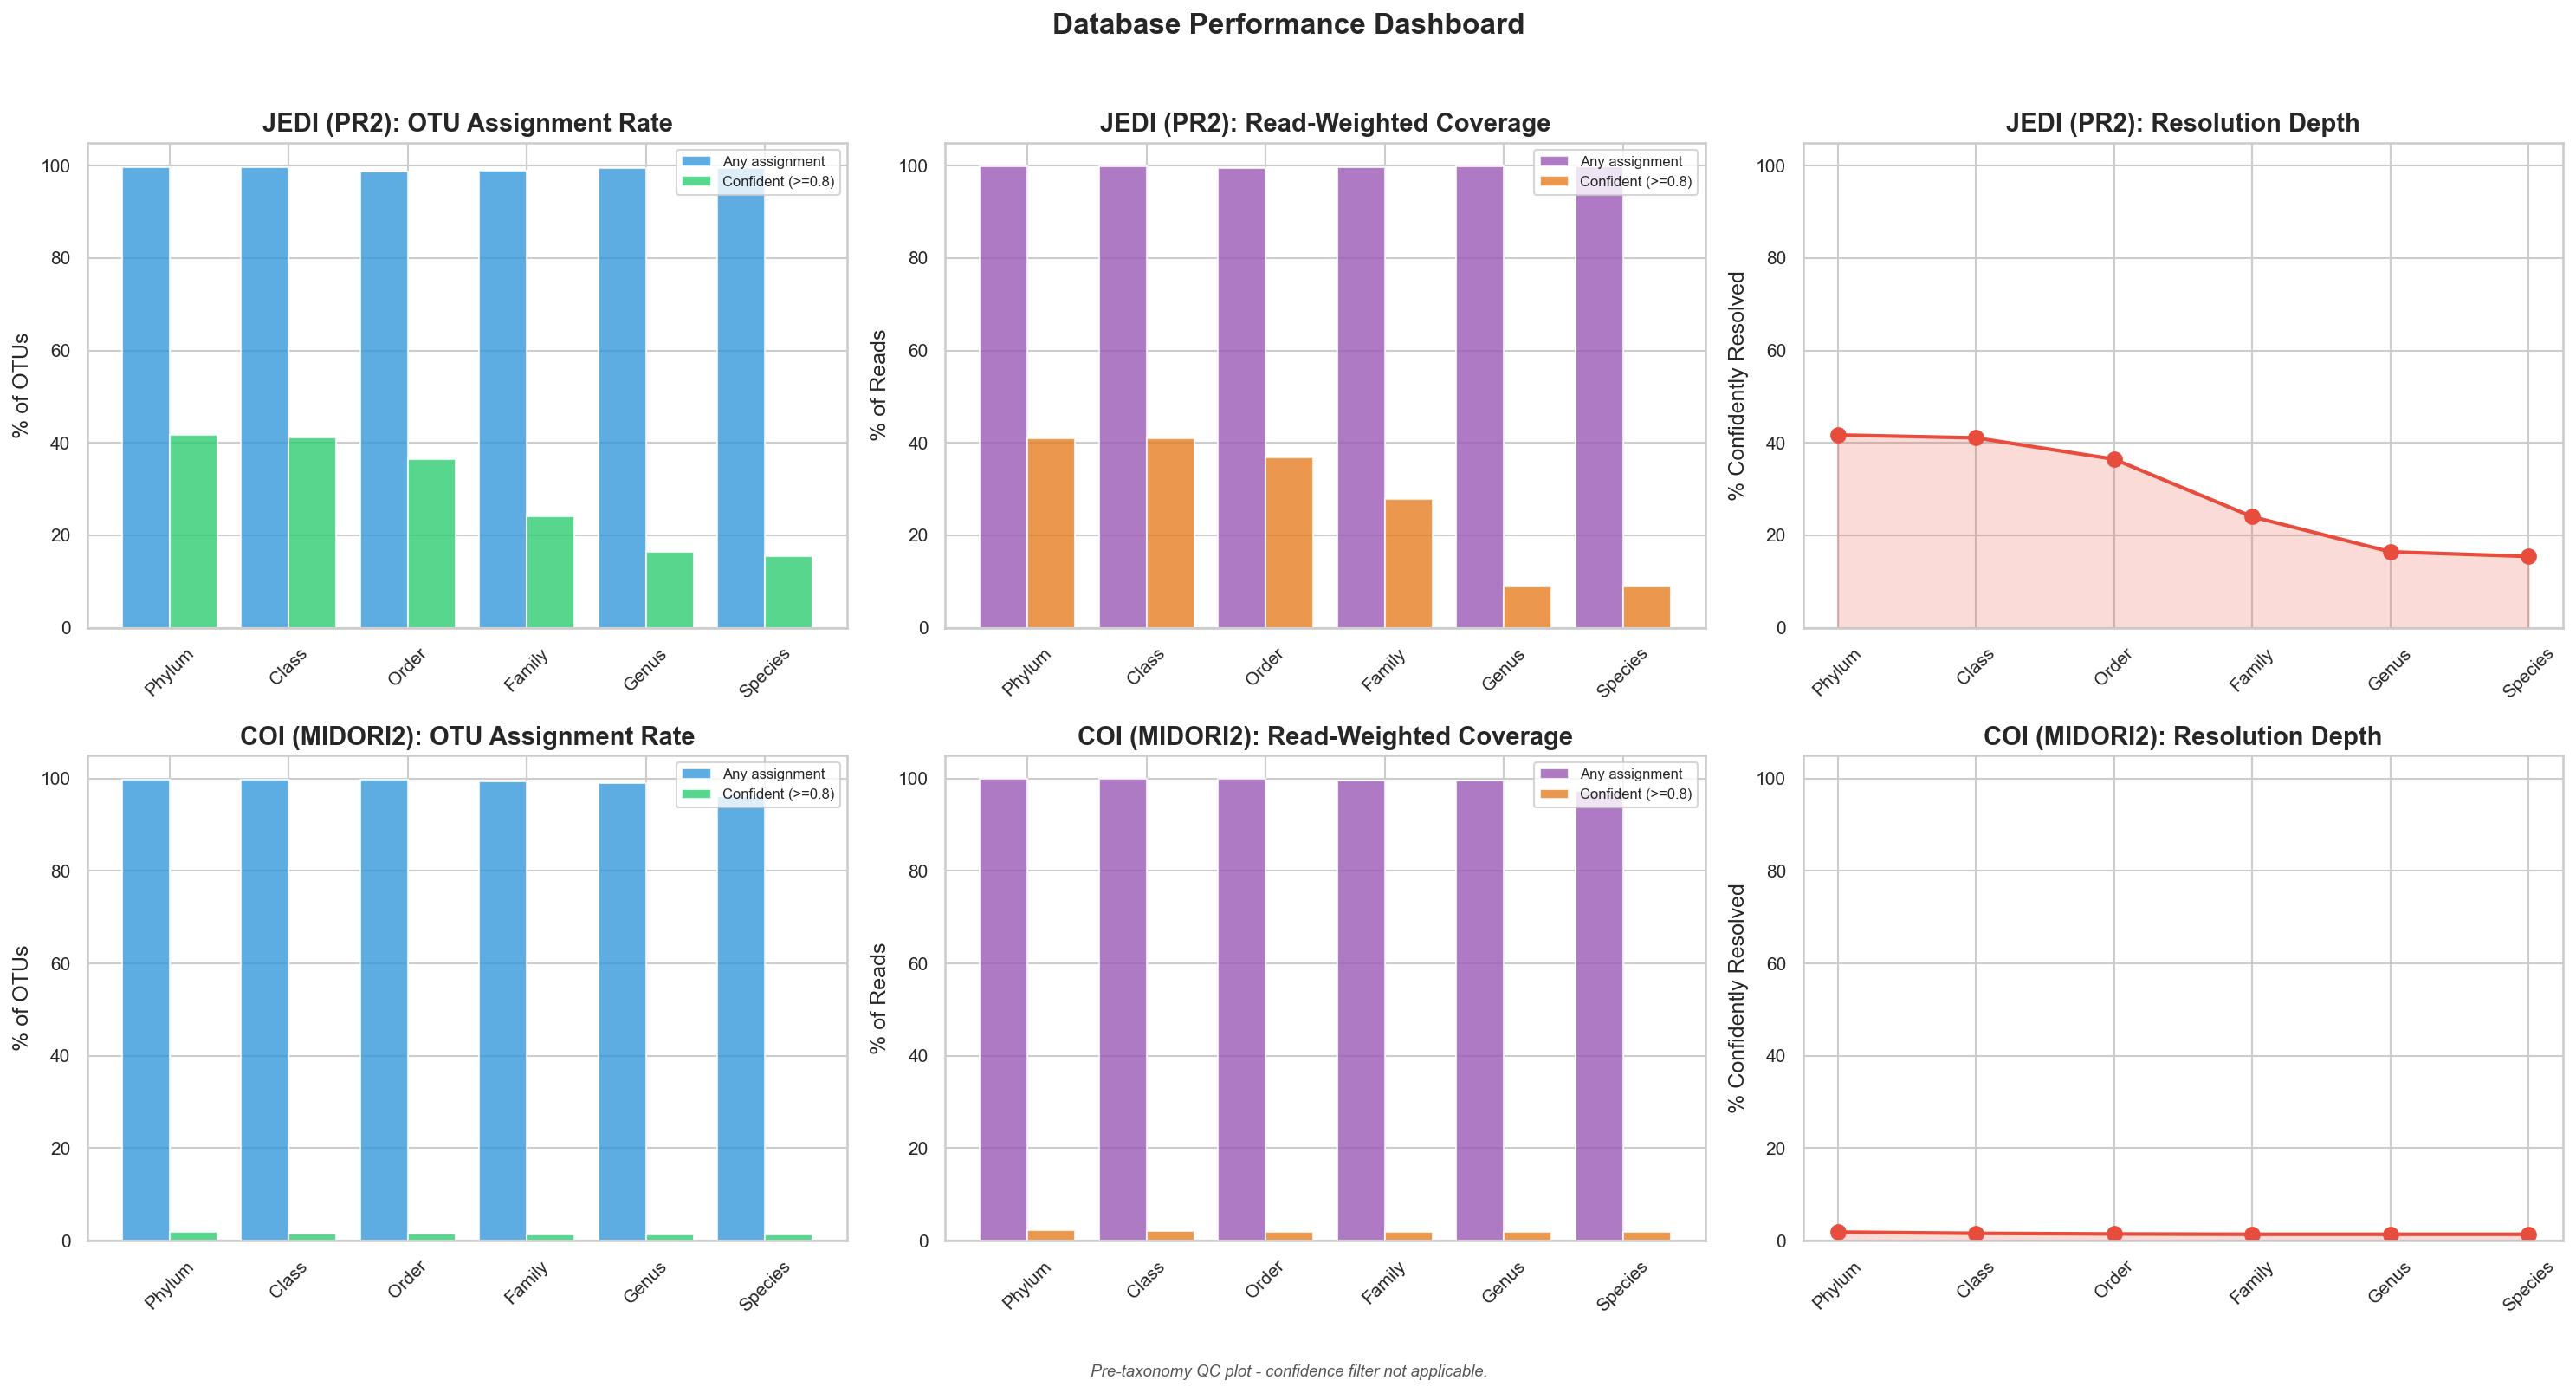

In [4]:
db_performance_dashboard([
    (df_jedi_raw, prefix_jedi, f'JEDI ({prefix_jedi})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Raw Read Length Distributions (Pre-Clustering)
Expected: JEDI ~400-550bp (515F-Y/926R), COI ~658bp (Folmer).

✓ JEDI: 52,569 reads, median=447bp, range=133-832bp
✓ COI: 25,247 reads, median=738bp, range=149-839bp


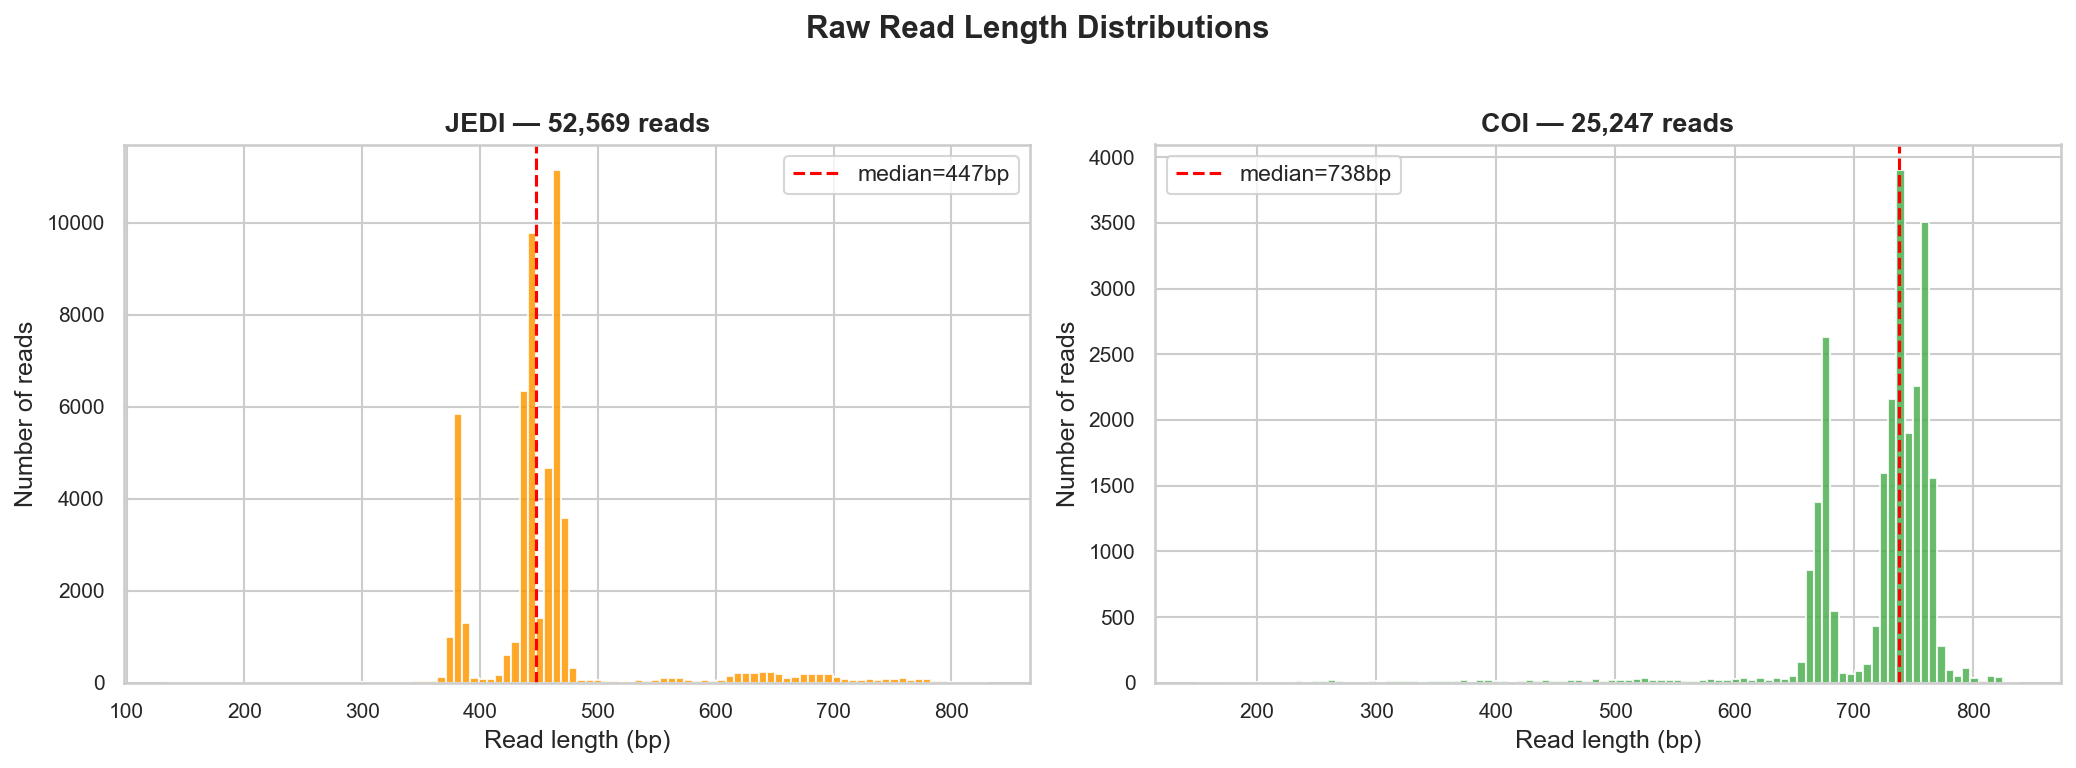

In [5]:
plot_read_lengths(BASE, MARKERS)

## Consensus OTU Sequence Length Distributions

✓ JEDI: 800 OTUs, median=670bp, range=265-933bp
✓ COI: 1500 OTUs, median=784bp, range=165-1144bp


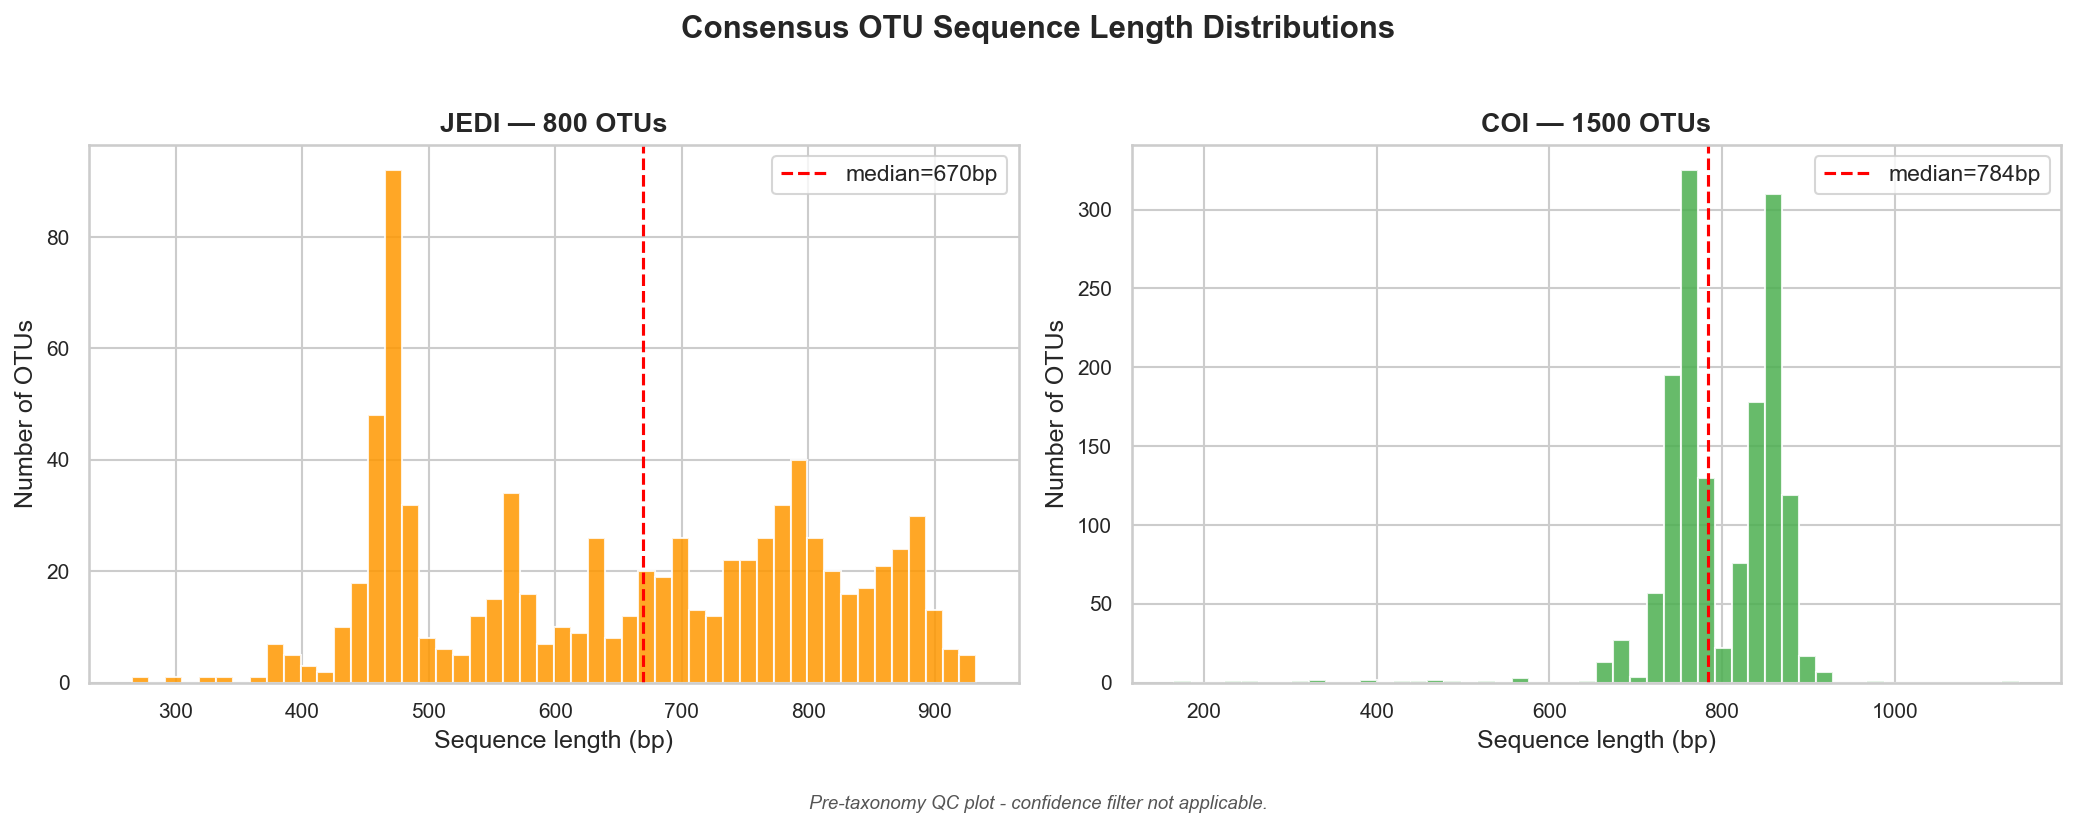

In [6]:
plot_consensus_lengths(BASE, MARKERS)

## Reads per OTU — Consensus Quality Assessment
Soil has many more OTUs (803 JEDI + 1503 COI) reflecting high soil biodiversity.

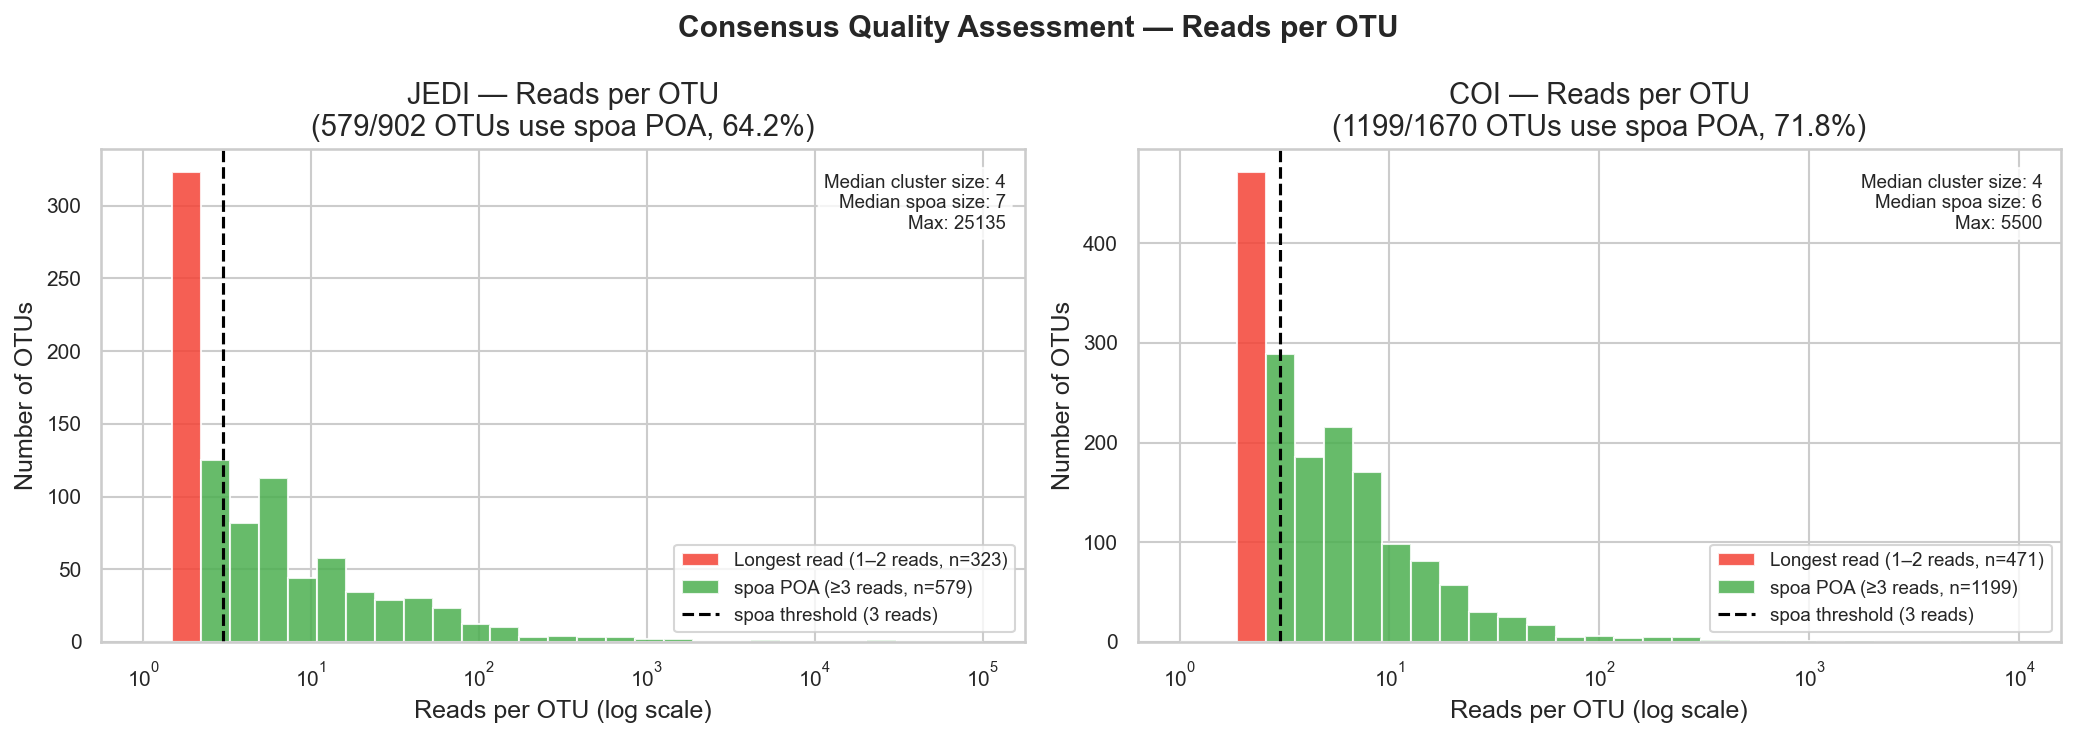

Marker     Total OTUs    spoa (≥3)  Longest rd (<3)   % spoa   Median reads  Max reads
--------------------------------------------------------------------------------
JEDI              902          579              323    64.2%              4      25135
COI              1670         1199              471    71.8%              4       5500


In [7]:
plot_reads_per_otu(BASE, MARKERS)

## Read Length Distributions: Before vs After Primer Trimming

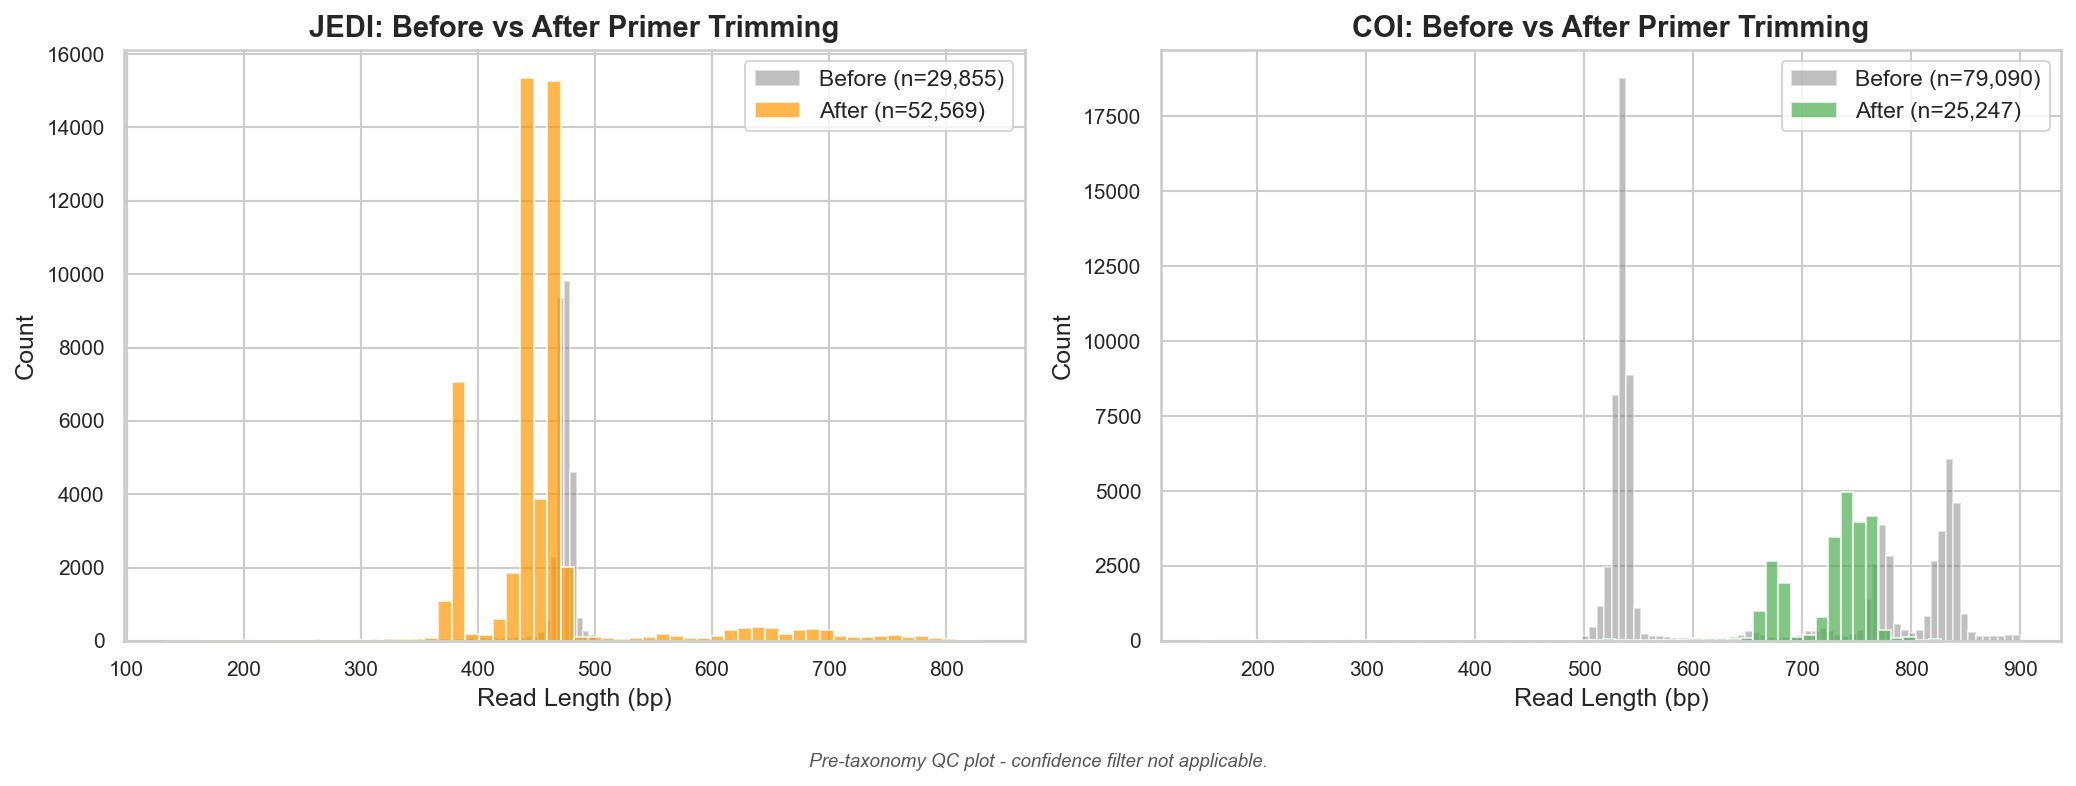

In [8]:
plot_primer_trimming(BASE, MARKERS)

## Reads per Barcode

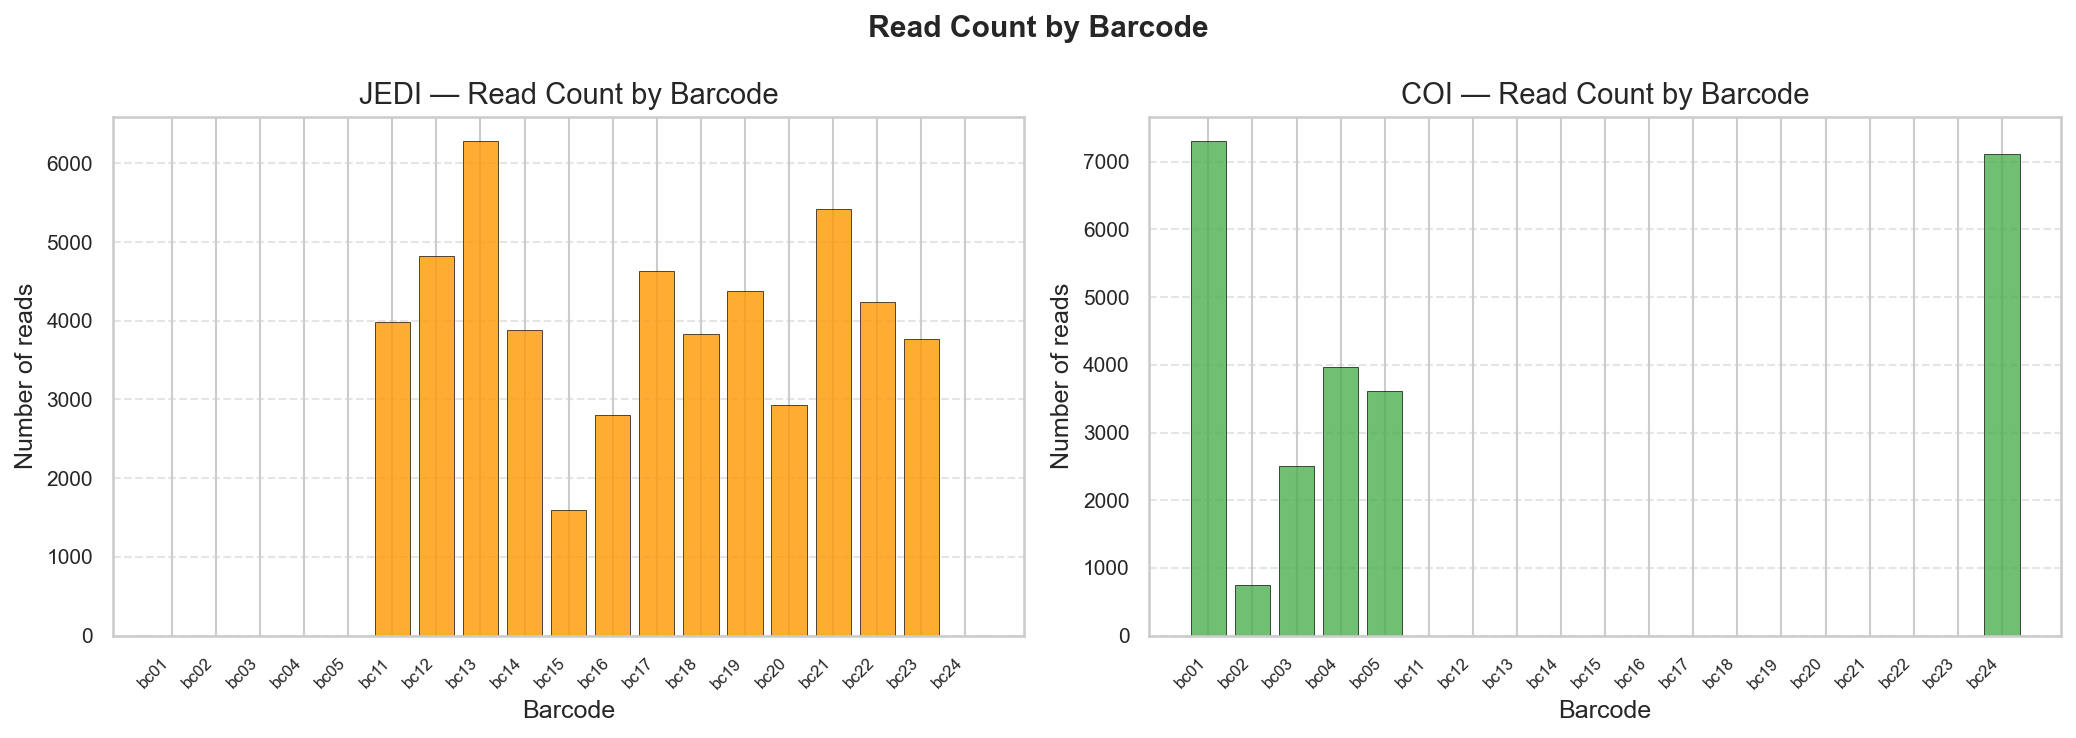

In [9]:
plot_barcode_reads(BASE, MARKERS)

# Part A: JEDI Marker Biodiversity Analysis (PR2)

*Objective: Characterize soil eukaryotic community using JEDI (18S V4 region) with PR2.*

- **Target:** Broad eukaryotic diversity (protists, fungi, micro-metazoa, diatoms)
- **Amplicon:** ~400-550 bp (515F-Y / 926R primers)
- **OTUs:** 803 (post-chimera removal)
- **Database:** PR2
- **Key finding:** JEDI captures excellent soil eukaryote diversity

## A.1a Broad Taxonomic Structure — Phylum

[JEDI] Phylum: Unassigned = 57.9% of reads


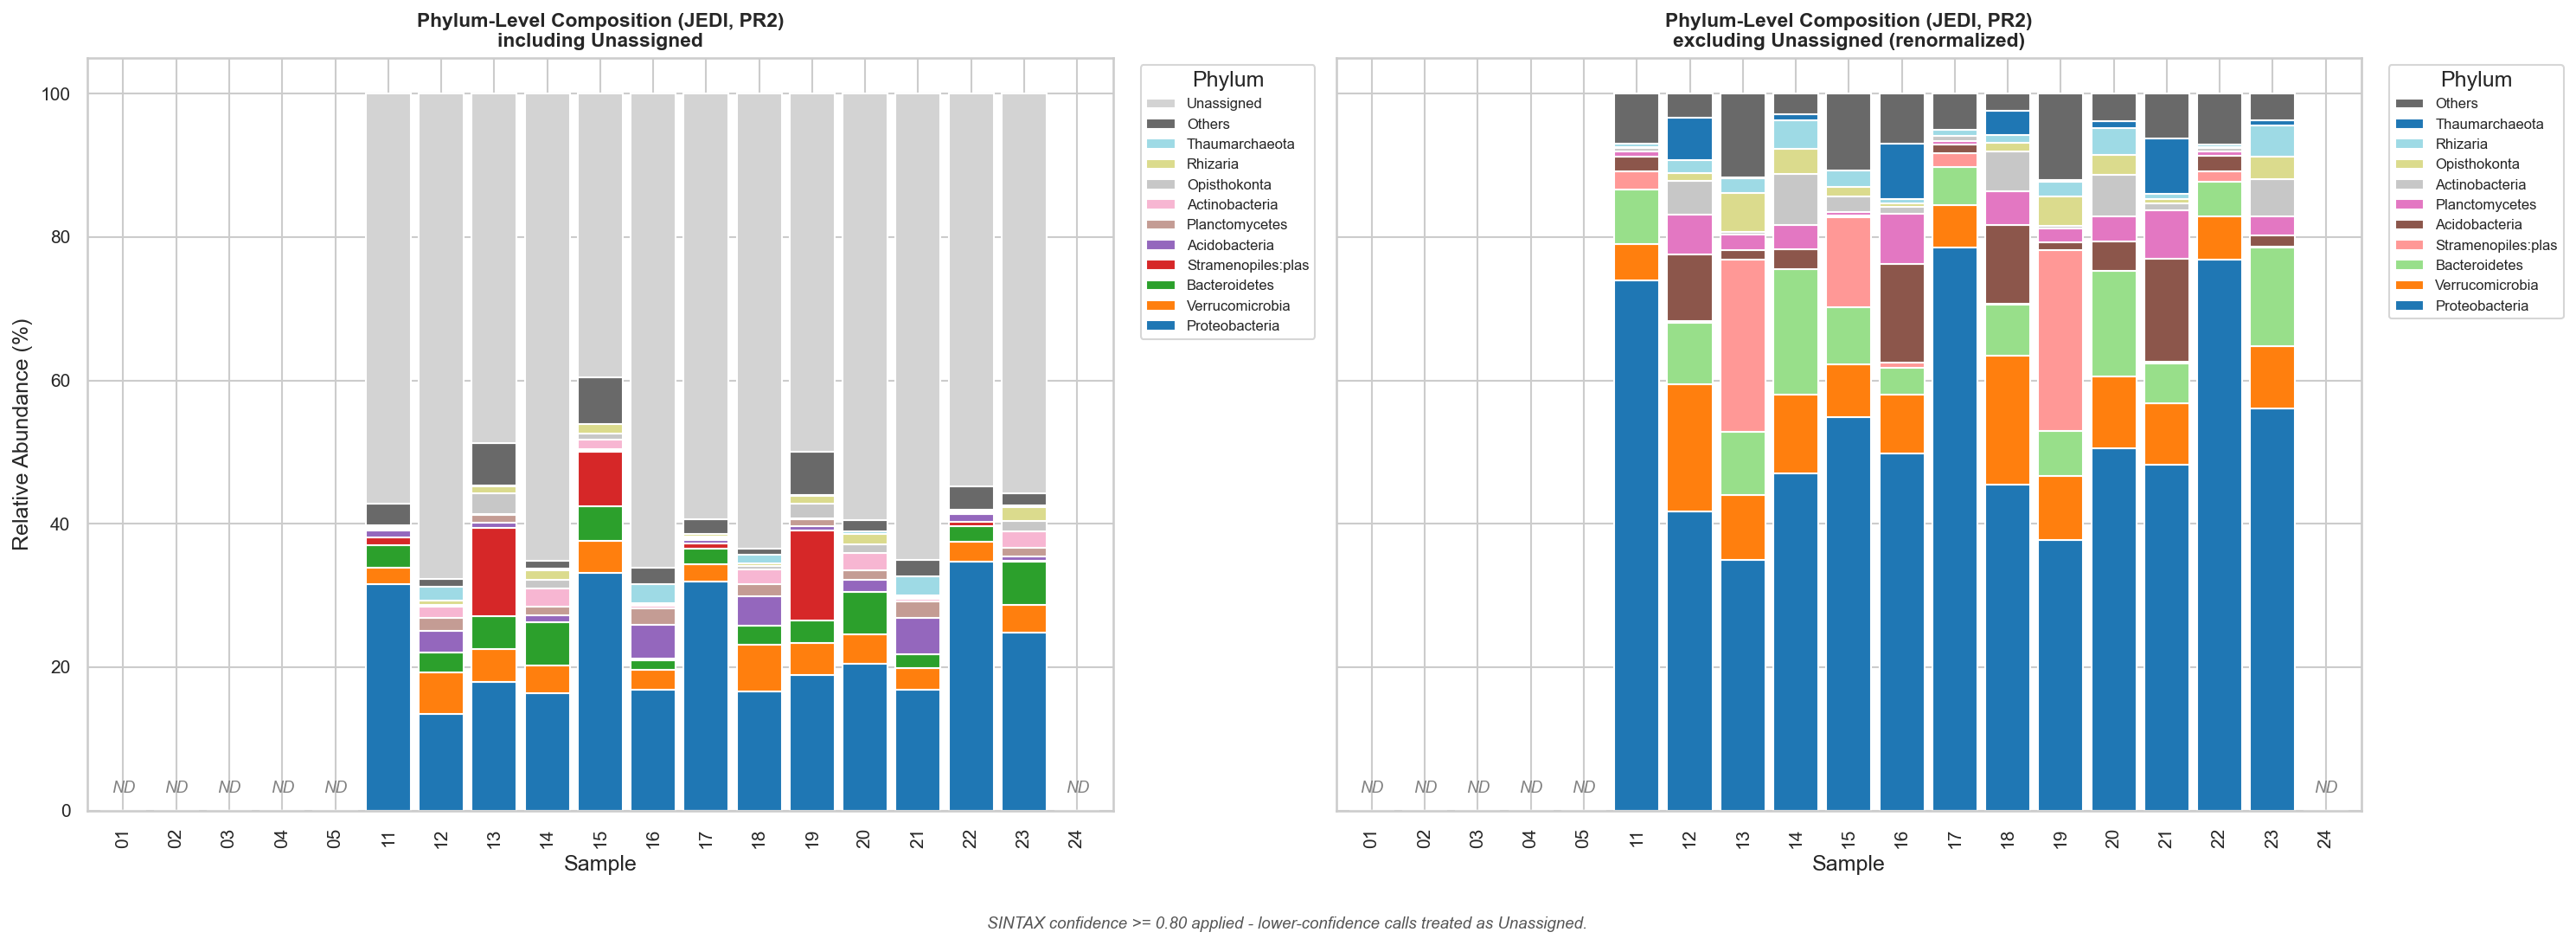

In [10]:
sample_cols_jedi = get_sample_cols(df_jedi_raw)
stacked_bar_compare(df_jedi_raw, 'Phylum', prefix_jedi, 'JEDI', sample_cols_jedi, top_n=10)

## A.1b Class-Level Breakdown (JEDI/PR2)
Expected in soil: Bacillariophyceae (diatoms), Chrysophyceae, Cercozoa, Ciliophora.

[JEDI] Class: Unassigned = 57.9% of reads


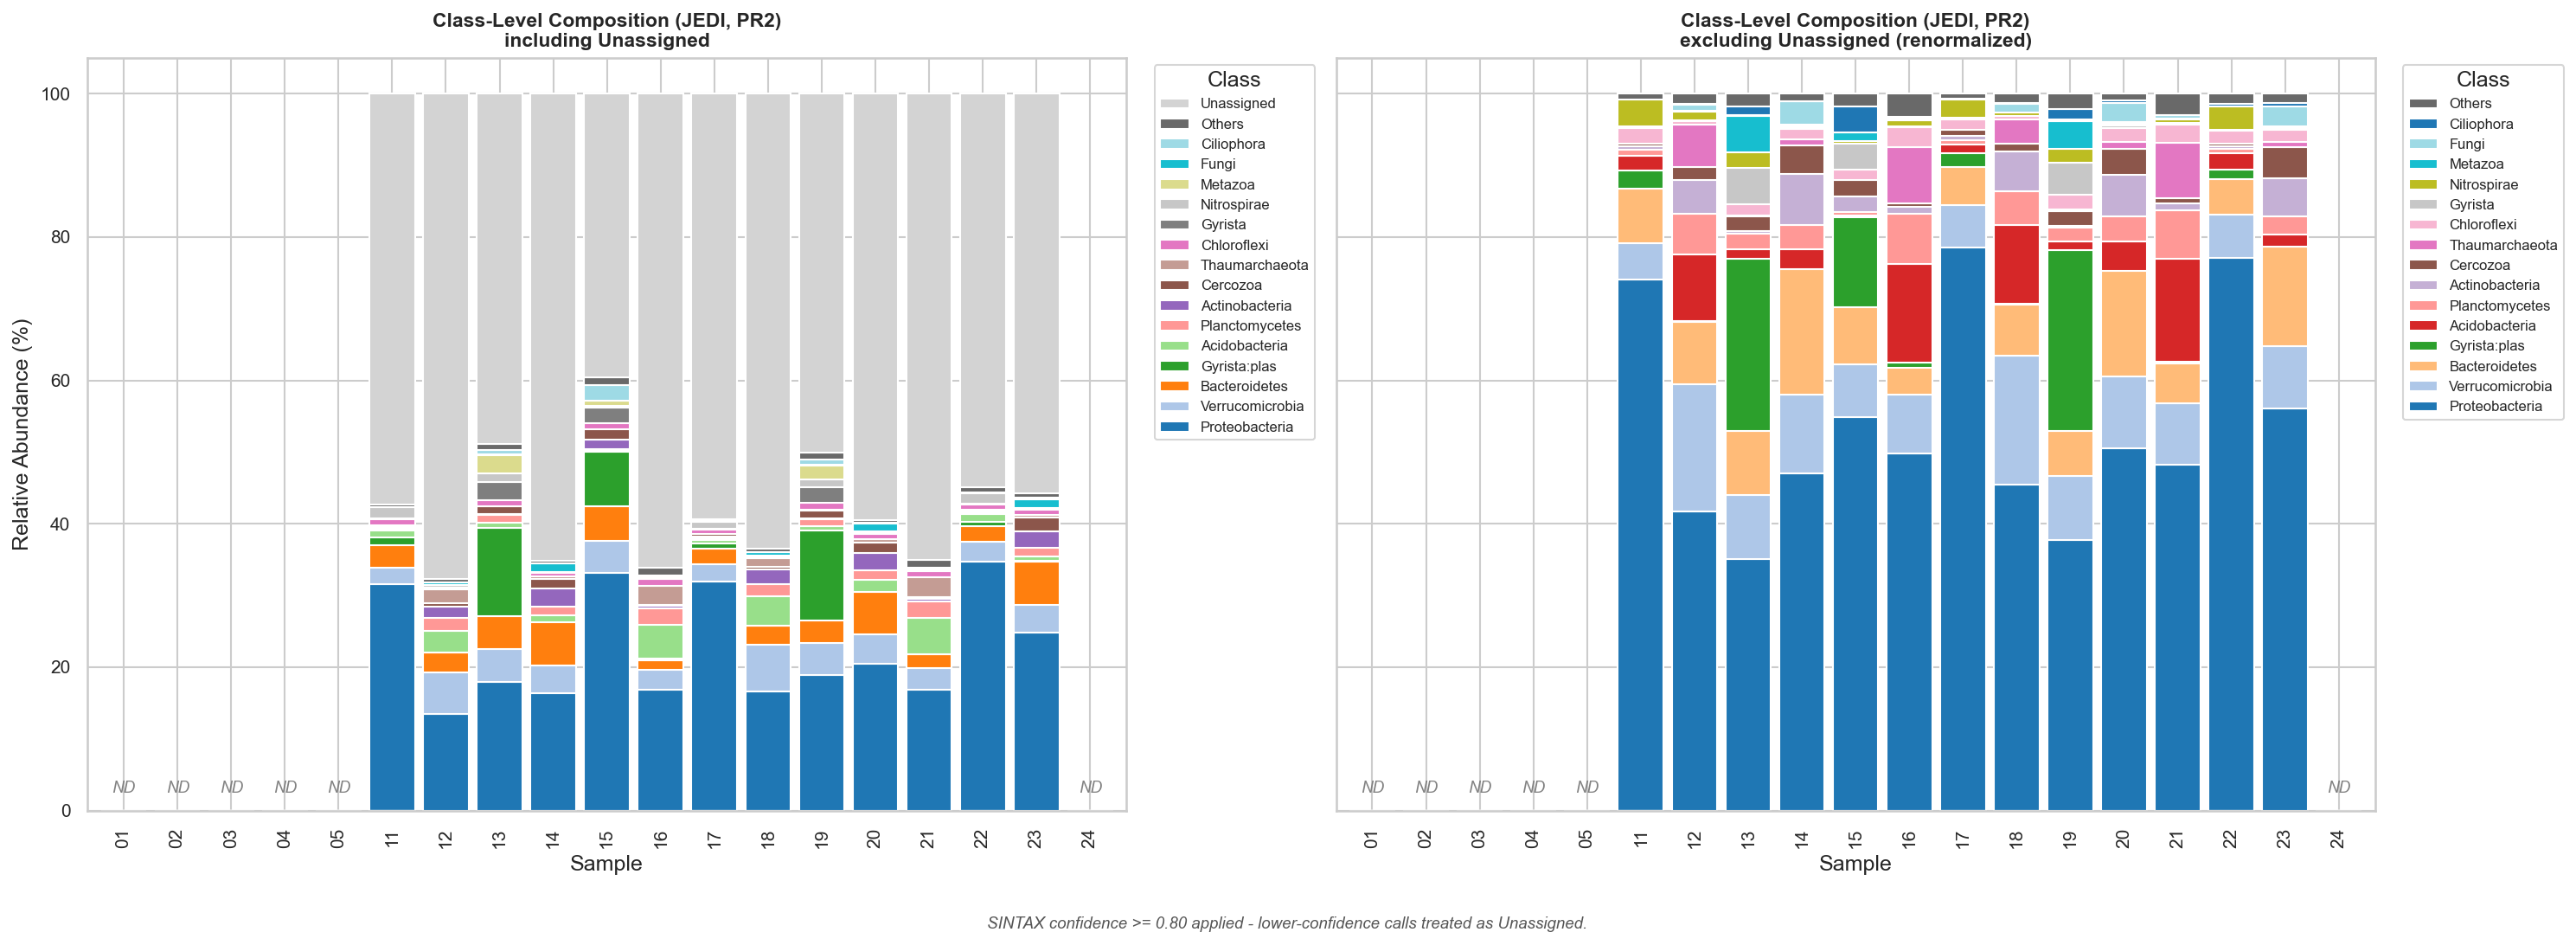

In [11]:
stacked_bar_compare(df_jedi_raw, 'Class', prefix_jedi, 'JEDI', sample_cols_jedi, top_n=15)

## A.2 Order-Level Breakdown (JEDI)

[JEDI] Order: Unassigned = 62.2% of reads


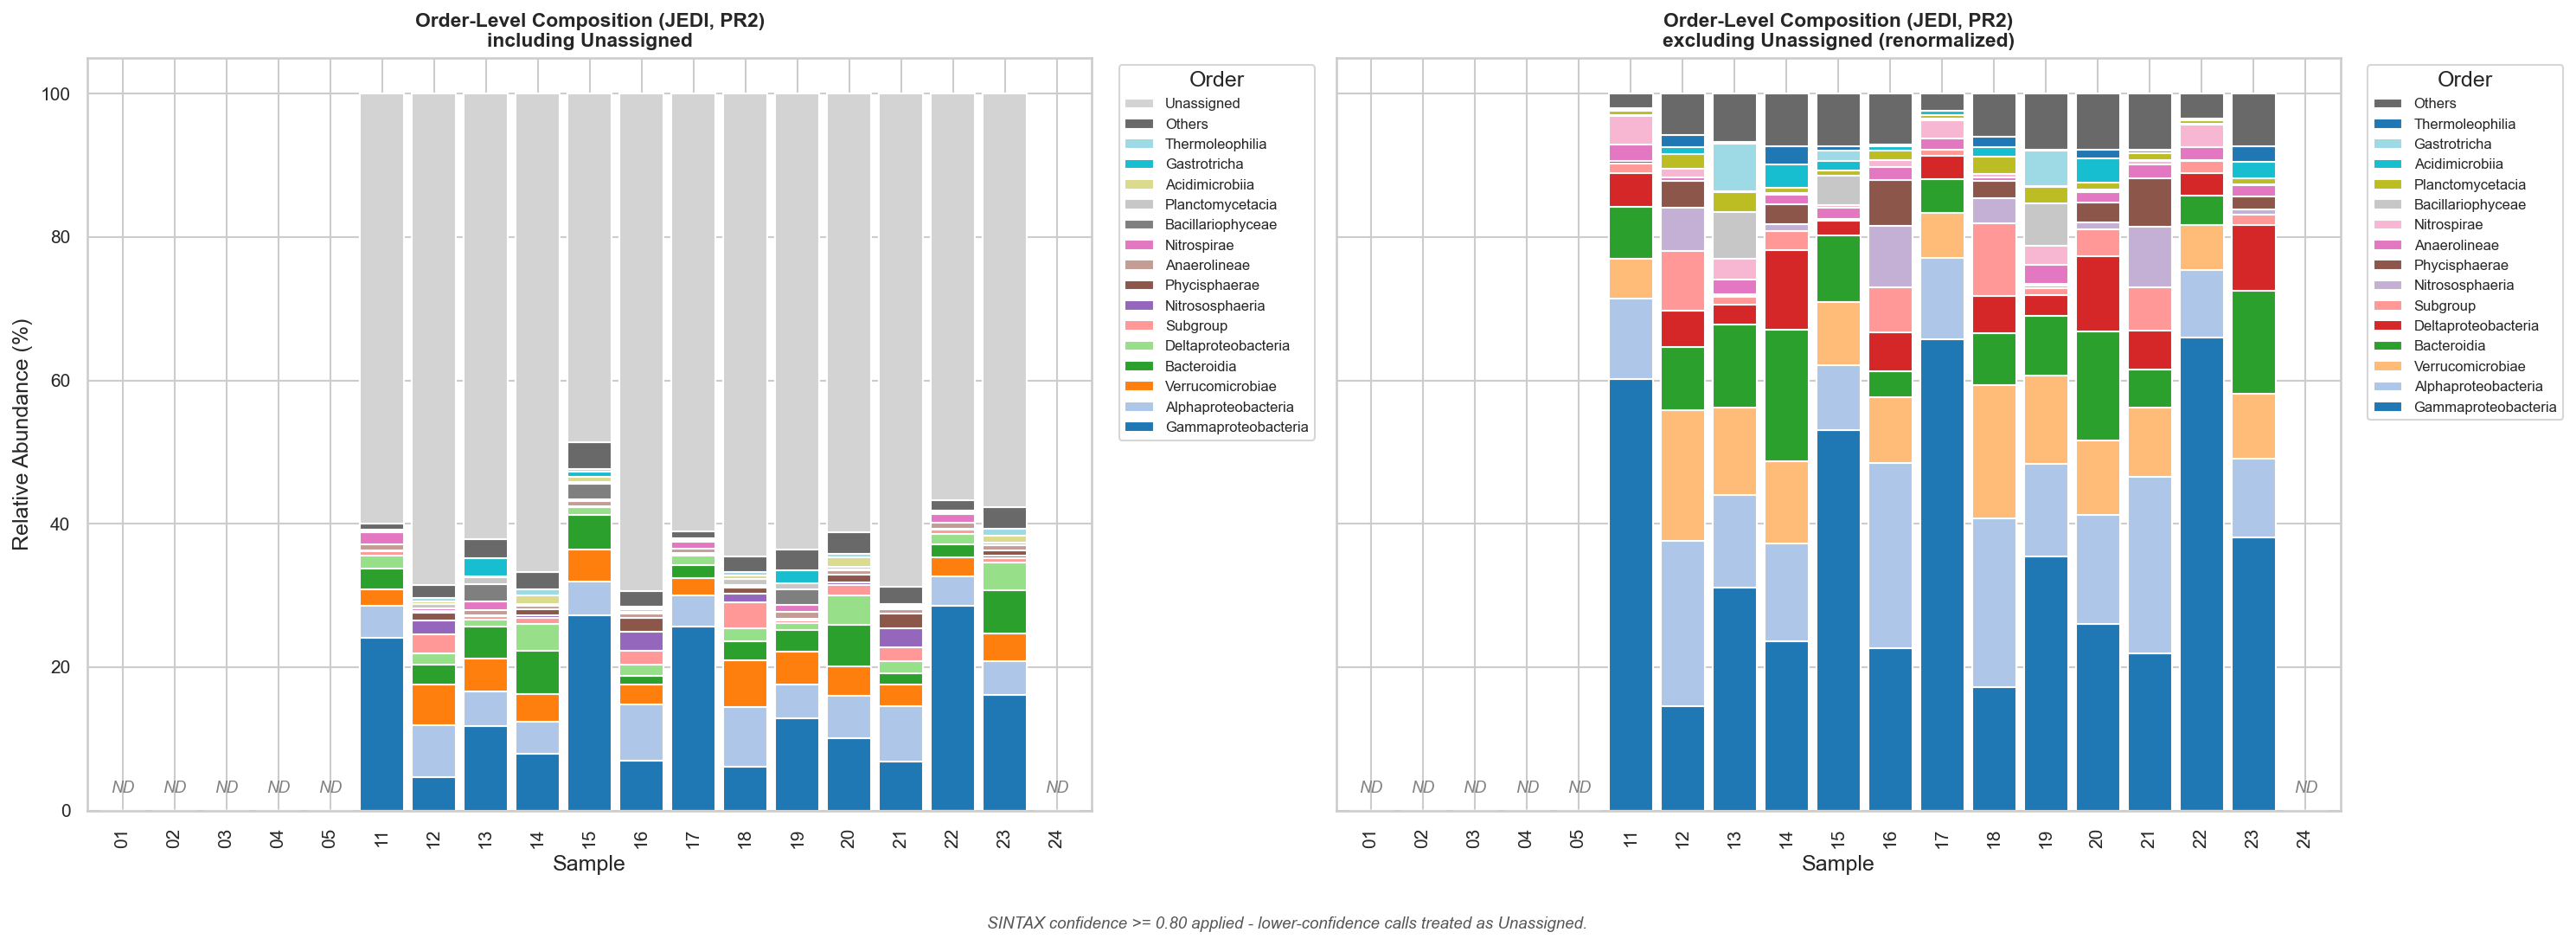

In [12]:
stacked_bar_compare(df_jedi_raw, 'Order', prefix_jedi, 'JEDI', sample_cols_jedi, top_n=15)

## A.3 Genus-Level Top 20 (JEDI)
Top genera with confident assignments.

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:622: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


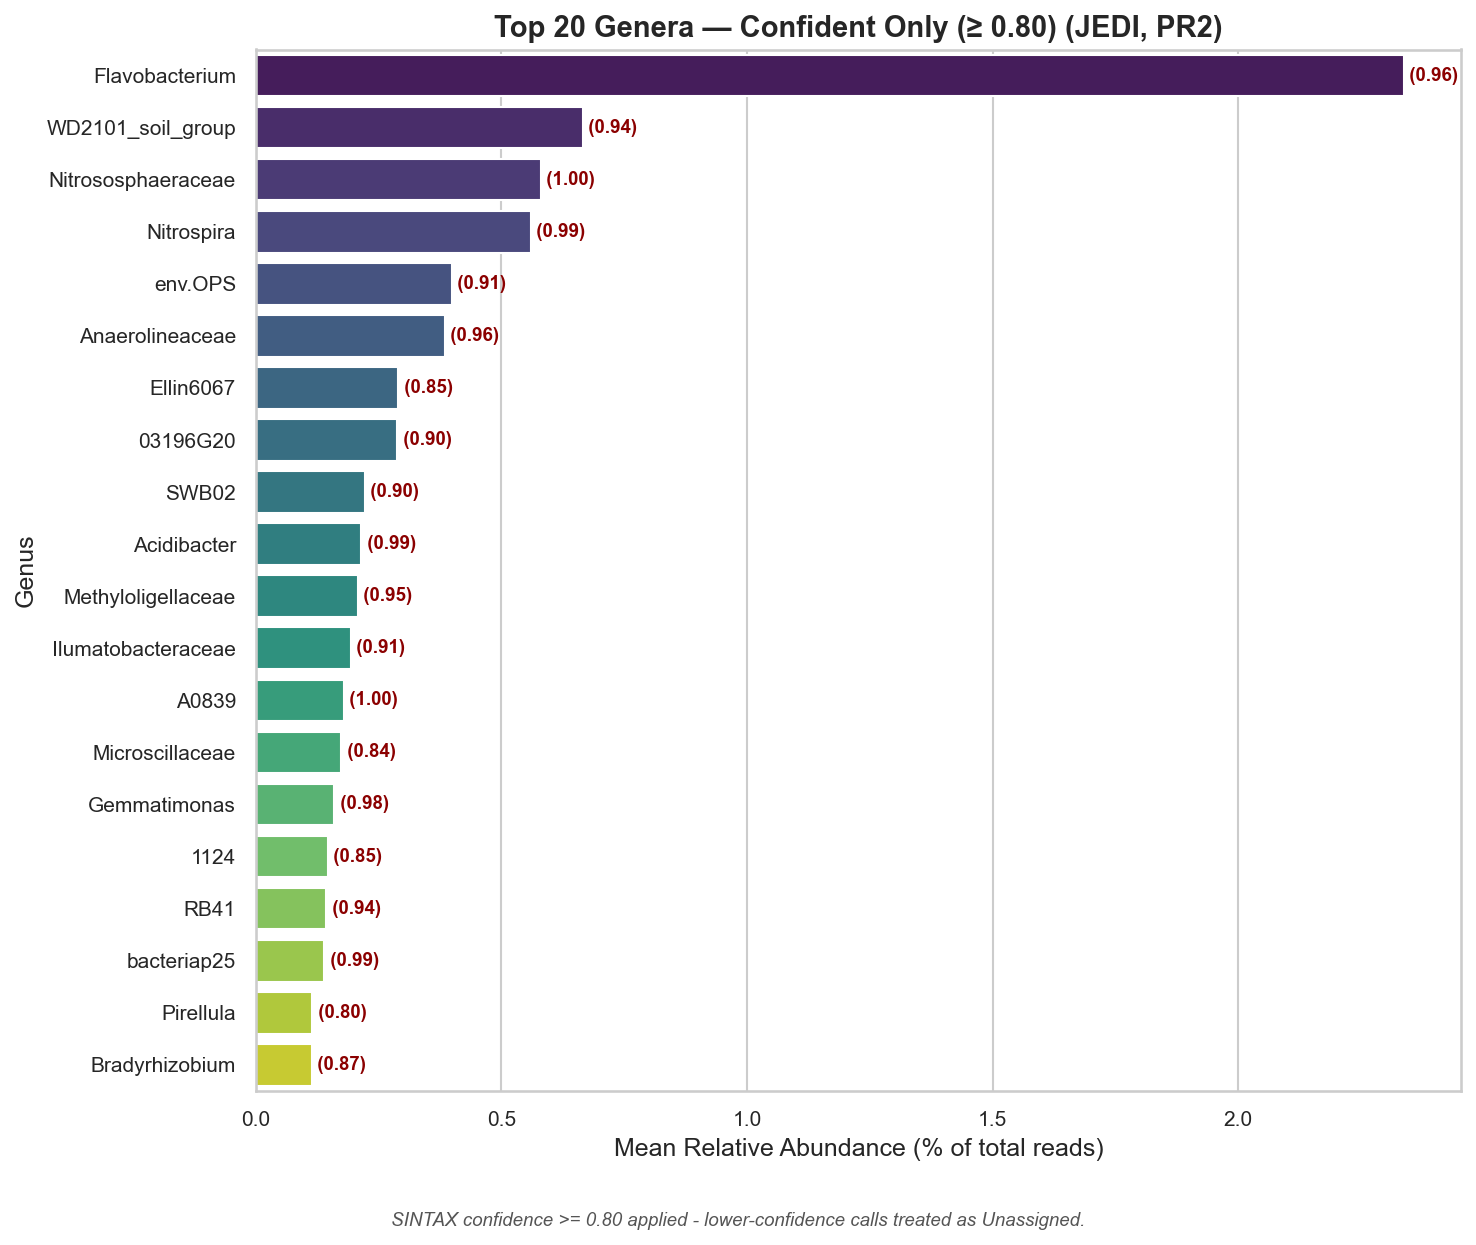

In [13]:
plot_top_genera_confident(df_jedi_raw, prefix_jedi, 'JEDI', sample_cols_jedi)

### Top 20 Genera by Abundance — All Confidences (JEDI)

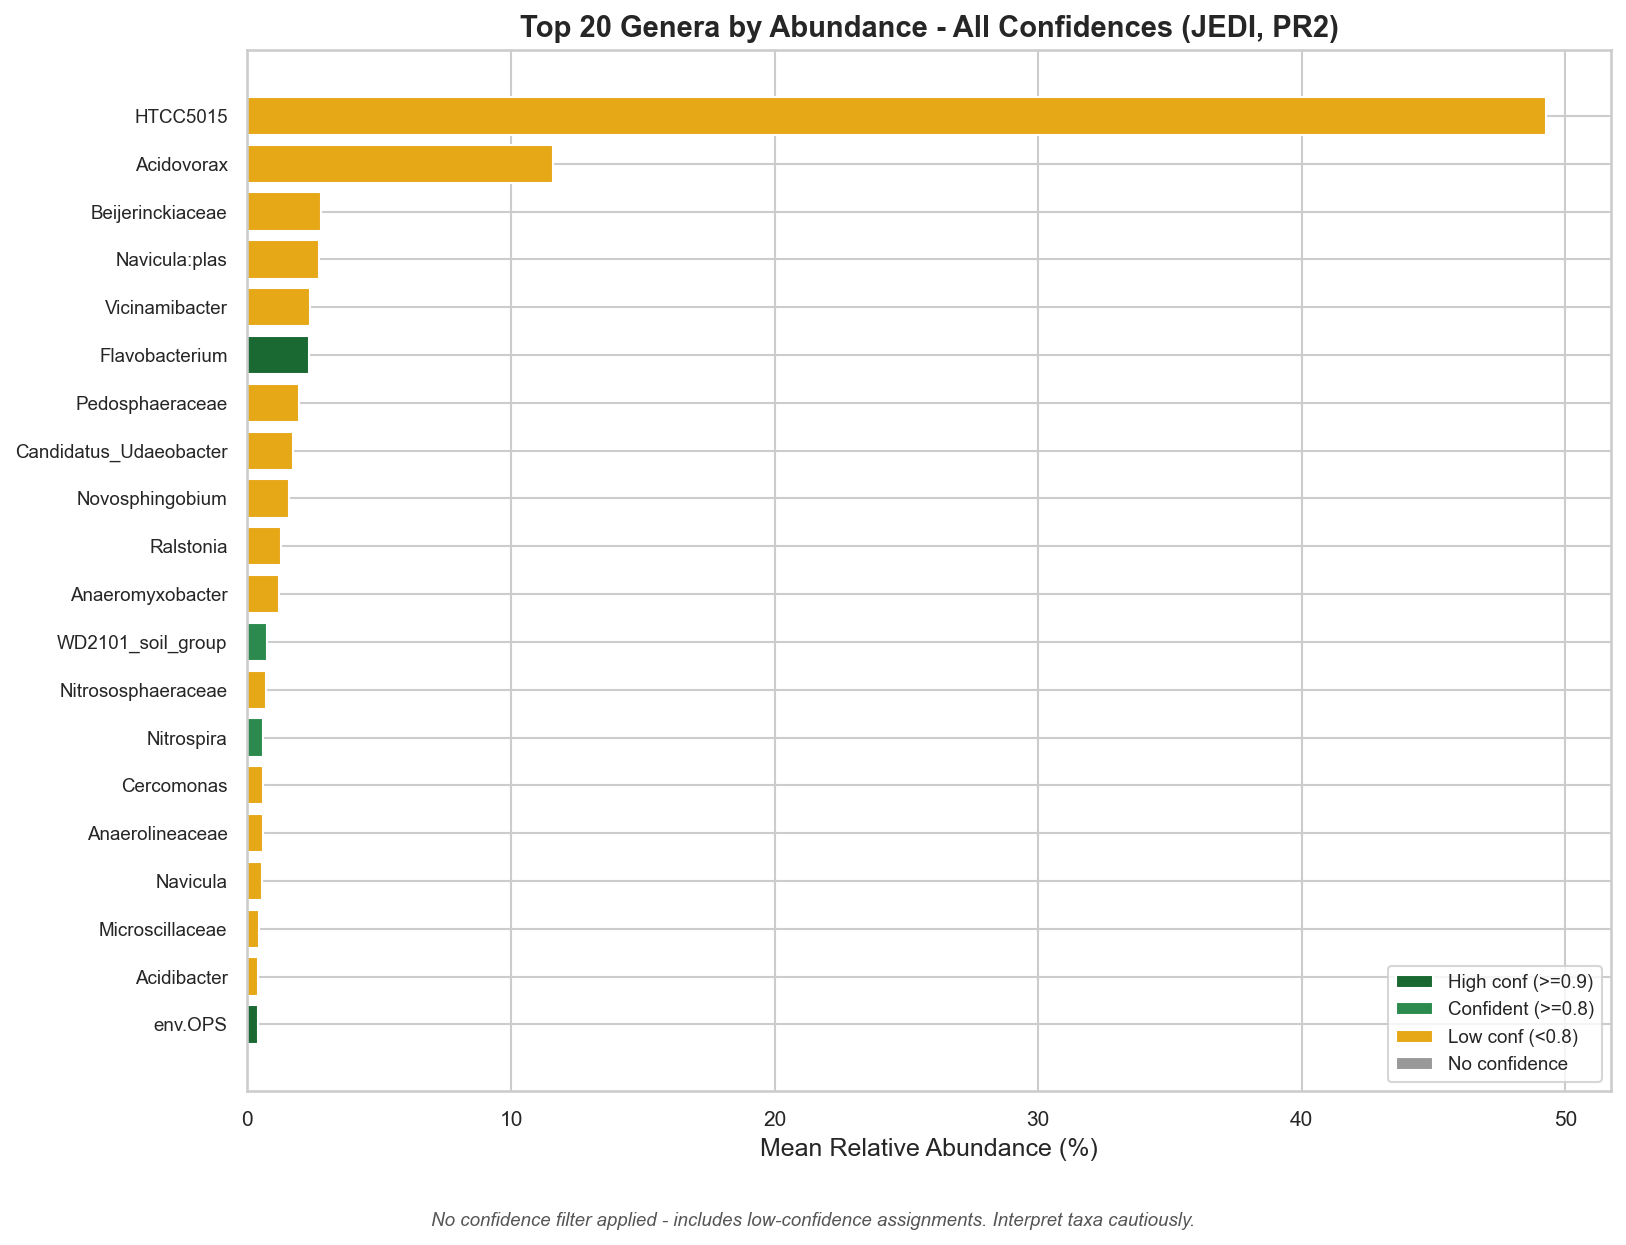

In [14]:
plot_top_genera_all(df_jedi_raw, prefix_jedi, 'JEDI', sample_cols_jedi)

## A.3b Top 20 Eukaryotic Genera (JEDI, PR2)
Filtered to Eukaryota with confidence >= 0.8.

Eukaryota filter: 297/803 OTUs (37.0%)


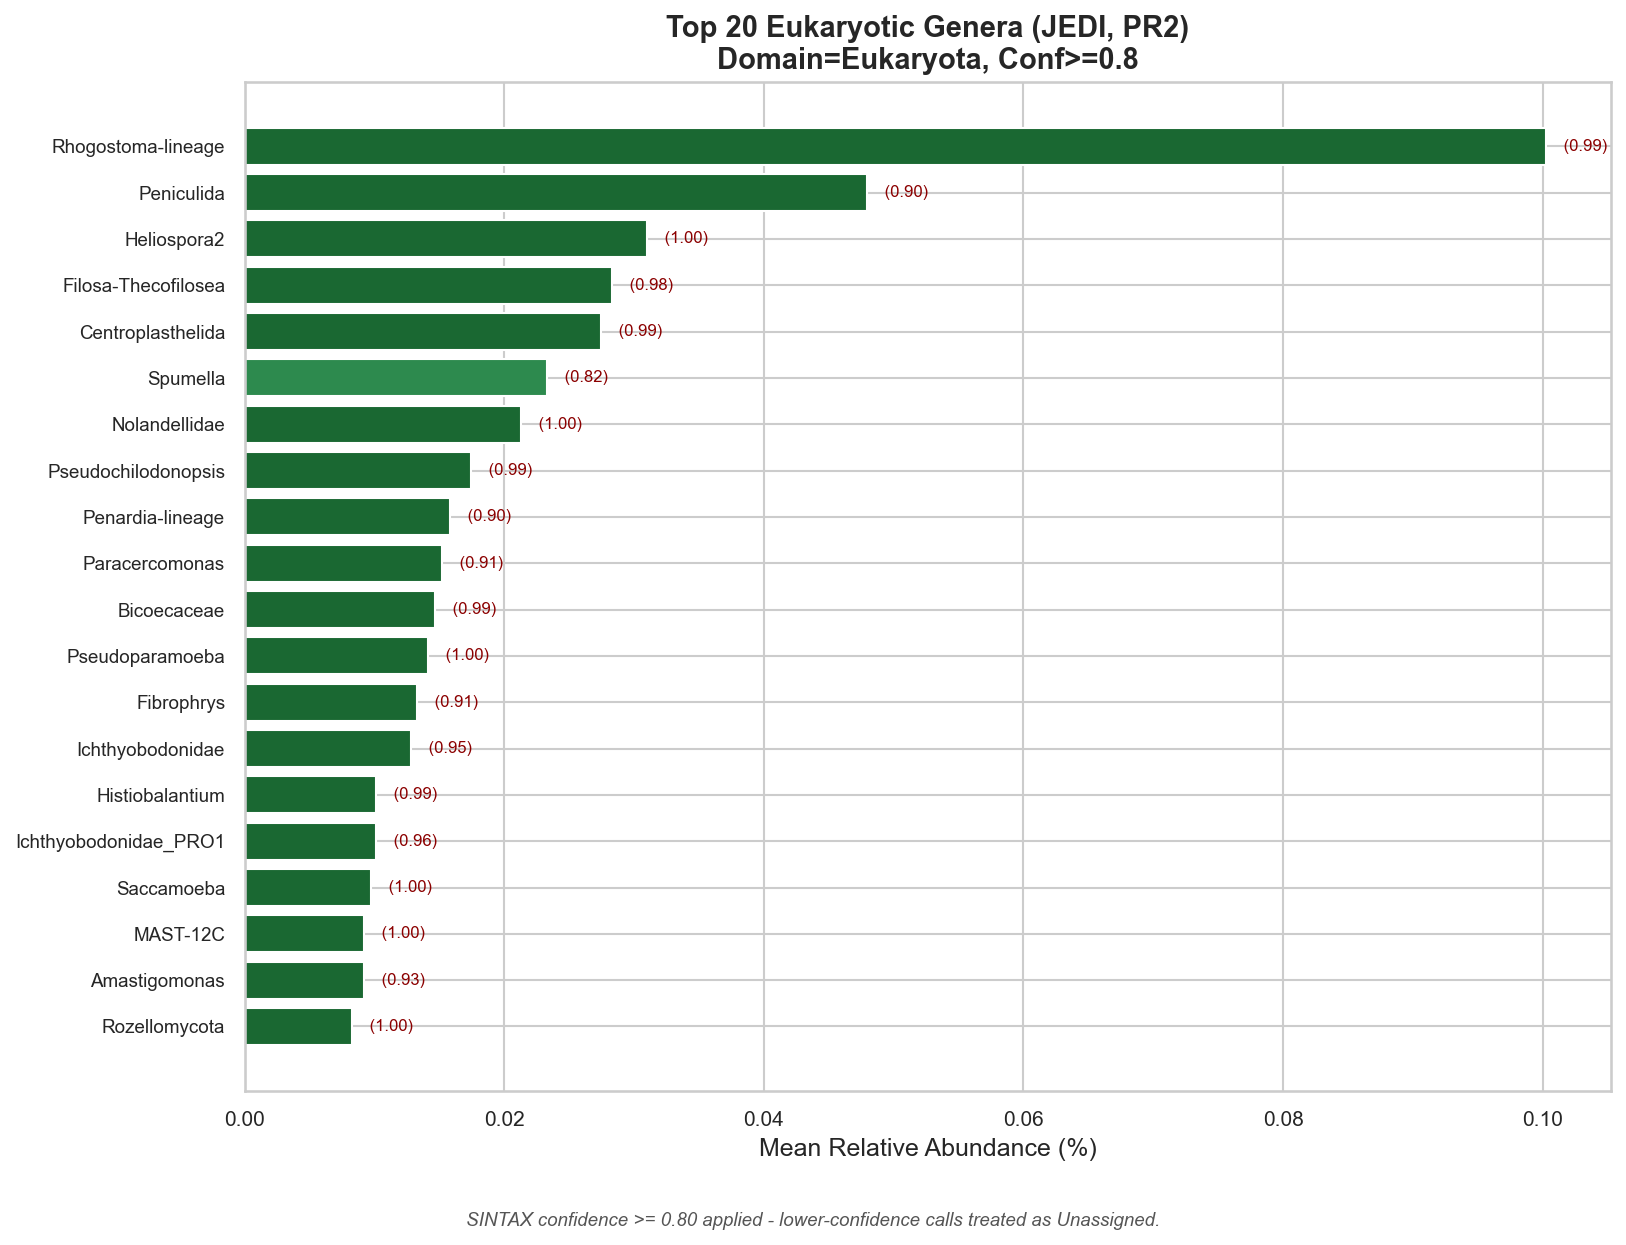

In [15]:
plot_eukaryotic_genera(df_jedi_raw, prefix_jedi, 'JEDI', sample_cols_jedi)

## BLAST Validation — JEDI

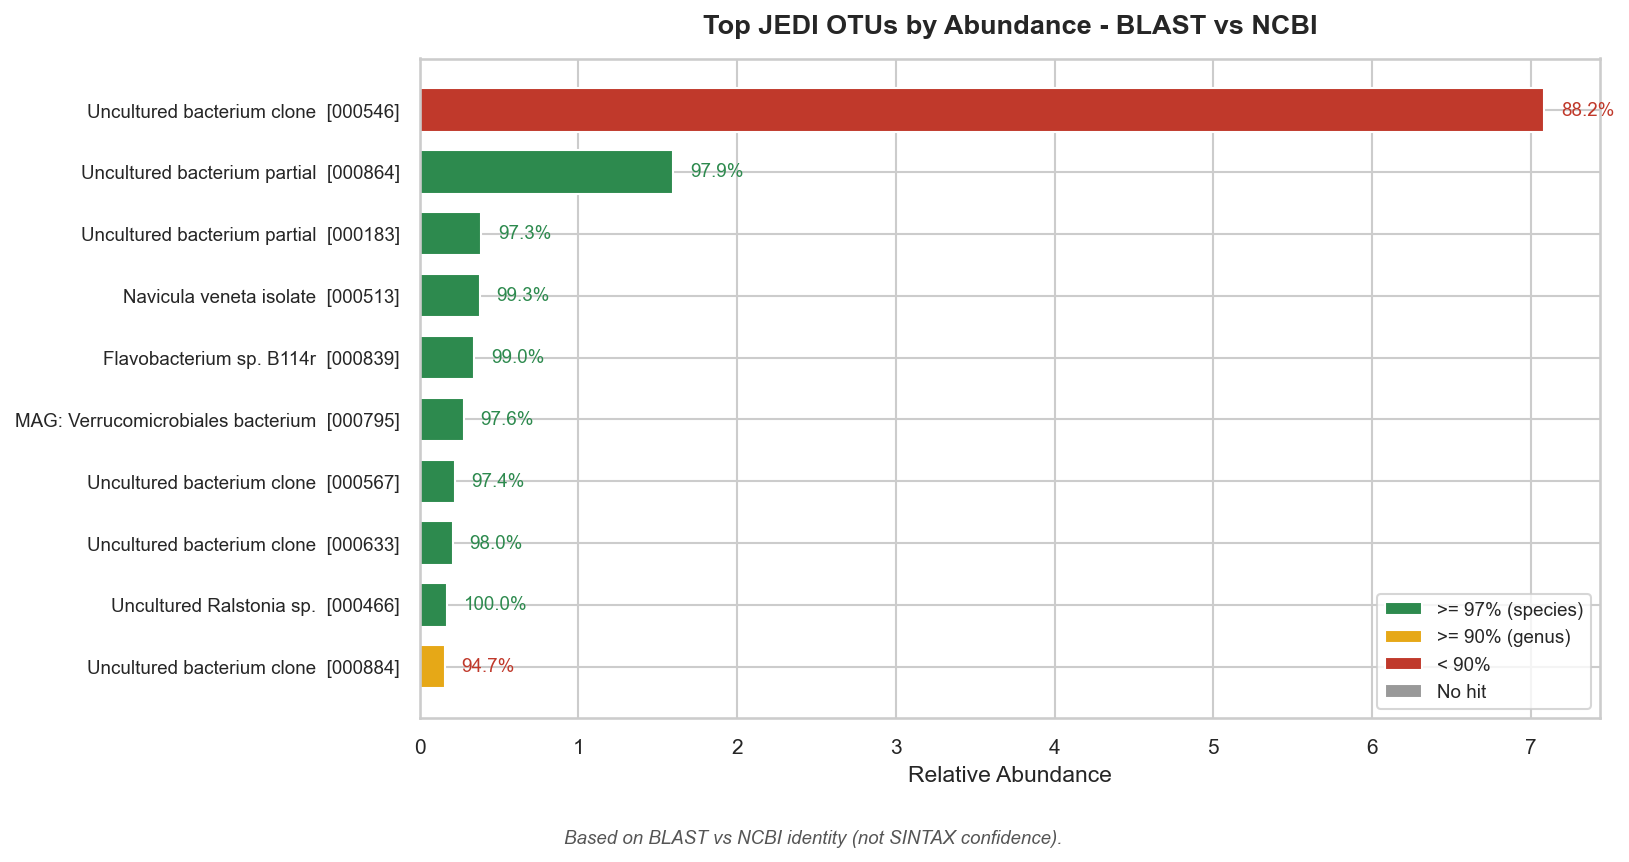

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:877: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),Phylum,Class,Order,Family,Genus,Species
OTU_JEDI_000546,7.0826,Uncultured bacterium clone,88.2%,Proteobacteria (0.51),Proteobacteria (0.51),Gammaproteobacteria (0.27),Arenicellaceae (0.06),HTCC5015 (0.05),HTCC5015 (0.05)
OTU_JEDI_000864,1.5973,Uncultured bacterium partial,97.9%,Proteobacteria (1.00),Proteobacteria (1.00),Gammaproteobacteria (1.00),Burkholderiaceae (0.97),Acidovorax (0.24),Acidovorax (0.24)
OTU_JEDI_000183,0.3899,Uncultured bacterium partial,97.3%,Proteobacteria (1.00),Proteobacteria (1.00),Alphaproteobacteria (1.00),Beijerinckiaceae (0.56),Beijerinckiaceae (0.26),Beijerinckiaceae_X (0.26)
OTU_JEDI_000513,0.3794,Navicula veneta isolate,99.3%,Stramenopiles:plas (1.00),Gyrista:plas (1.00),Bacillariophyceae:plas (0.53),Naviculaceae:plas (0.19),Navicula:plas (0.18),Navicula_phyllepta:plas (0.12)
OTU_JEDI_000839,0.3436,Flavobacterium sp. B114r,99.0%,Bacteroidetes (0.98),Bacteroidetes (0.98),Bacteroidia (0.98),Flavobacteriaceae (0.98),Flavobacterium (0.96),Flavobacterium (0.96)
OTU_JEDI_000795,0.2780,MAG: Verrucomicrobiales bacterium,97.6%,Verrucomicrobia (0.80),Verrucomicrobia (0.80),Verrucomicrobiae (0.80),Pedosphaeraceae (0.75),Pedosphaeraceae (0.50),Pedosphaeraceae_X (0.50)
OTU_JEDI_000567,0.2215,Uncultured bacterium clone,97.4%,Verrucomicrobia (1.00),Verrucomicrobia (1.00),Verrucomicrobiae (1.00),Chthoniobacteraceae (0.97),Candidatus_Udaeobacter (0.70),Candidatus_Udaeobacter (0.70)
OTU_JEDI_000633,0.2086,Uncultured bacterium clone,98.0%,Proteobacteria (1.00),Proteobacteria (1.00),Alphaproteobacteria (1.00),Sphingomonadaceae (1.00),Novosphingobium (0.31),Novosphingobium (0.31)
OTU_JEDI_000466,0.1715,Uncultured Ralstonia sp.,100.0%,Proteobacteria (0.99),Proteobacteria (0.99),Gammaproteobacteria (0.99),Burkholderiaceae (0.97),Ralstonia (0.69),Ralstonia (0.69)
OTU_JEDI_000884,0.1596,Uncultured bacterium clone,94.7%,Proteobacteria (0.97),Proteobacteria (0.97),Deltaproteobacteria (0.94),Archangiaceae (0.16),Anaeromyxobacter (0.10),Anaeromyxobacter (0.10)


In [16]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_JEDI.txt'), 'JEDI', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_JEDI.txt'), df_jedi_raw, prefix_jedi, 'JEDI')

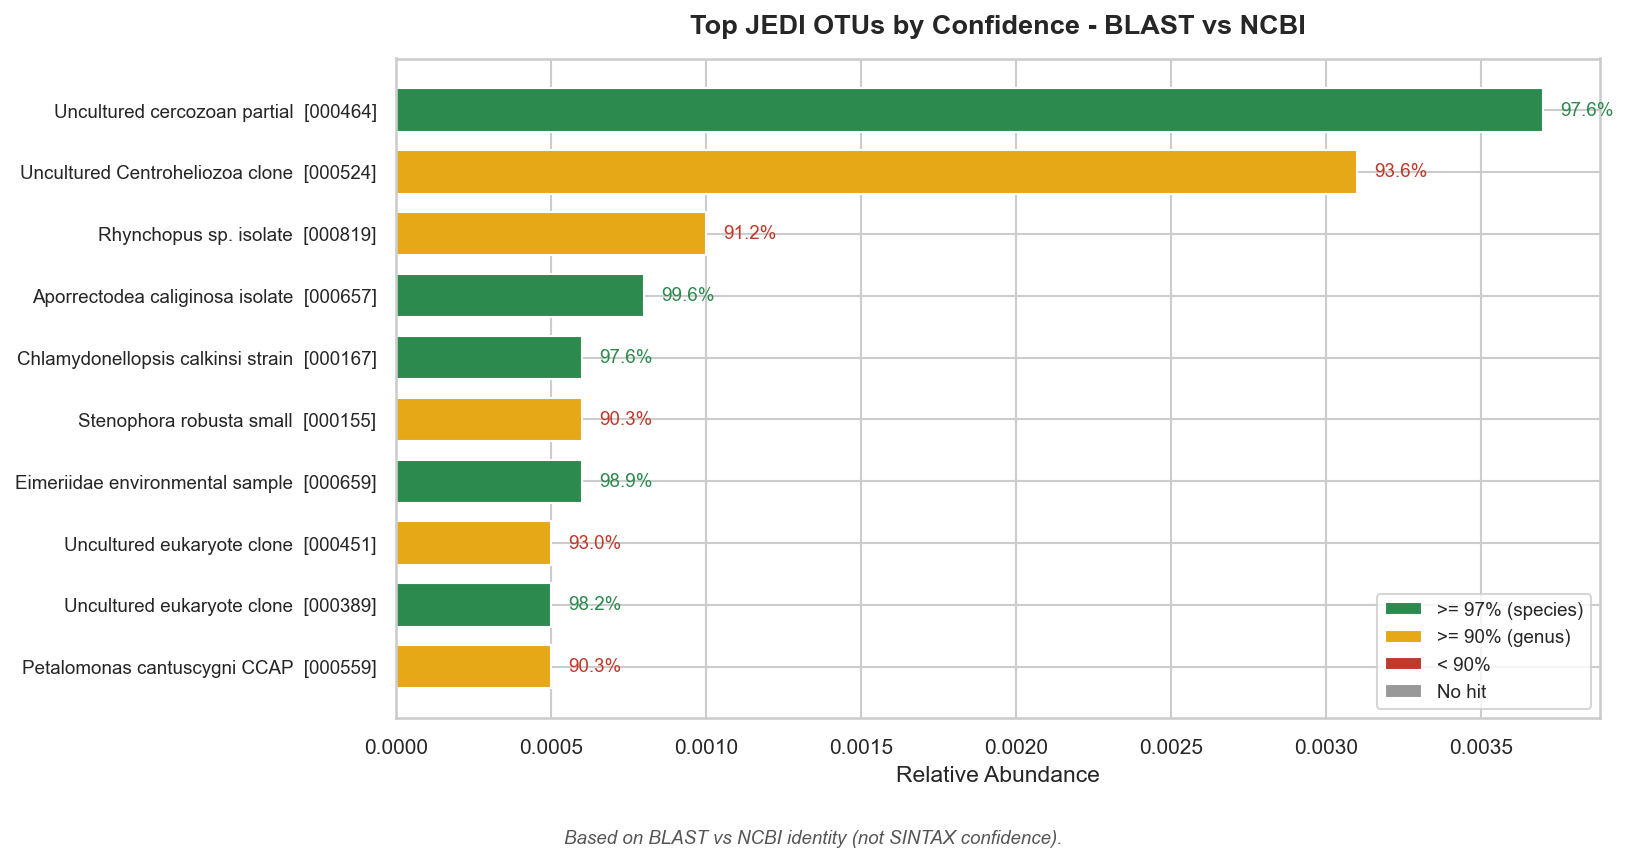

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:877: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),Phylum,Class,Order,Family,Genus,Species
OTU_JEDI_000167,0.0006,Chlamydonellopsis calkinsi strain,97.6%,Alveolata (1.00),Ciliophora (1.00),Phyllopharyngea (1.00),Lynchellidae (1.00),Chlamydonellopsis (0.99),Chlamydonellopsis_calkinsi (0.97)
OTU_JEDI_000819,0.0010,Rhynchopus sp. isolate,91.2%,Discoba (1.00),Euglenozoa (1.00),Diplonemea (1.00),Diplonemidae (0.98),Rhynchopus (0.92),Rhynchopus_humris (0.80)
OTU_JEDI_000659,0.0006,Eimeriidae environmental sample,98.9%,Opisthokonta (1.00),Fungi (1.00),Basidiomycota (1.00),Agaricomycetes (1.00),Agaricomycetes (1.00),Agaricomycetes_X (1.00)
OTU_JEDI_000559,0.0005,Petalomonas cantuscygni CCAP,90.3%,Discoba (1.00),Euglenozoa (1.00),Euglenida (1.00),Scytomonadidae (1.00),Petalomonas (1.00),Petalomonas_cantuscygni (1.00)
OTU_JEDI_000389,0.0005,Uncultured eukaryote clone,98.2%,Centroplasthelida (1.00),Centroplasthelida (1.00),Centroplasthelida (1.00),Centroplasthelida (1.00),Centroplasthelida (1.00),Centroplasthelida_XXXXX (1.00)
OTU_JEDI_000464,0.0037,Uncultured cercozoan partial,97.6%,Rhizaria (1.00),Cercozoa (1.00),Filosa-Thecofilosea (0.98),Filosa-Thecofilosea (0.98),Filosa-Thecofilosea (0.98),Filosa-Thecofilosea_XXX (0.98)
OTU_JEDI_000657,0.0008,Aporrectodea caliginosa isolate,99.6%,Opisthokonta (1.00),Metazoa (1.00),Annelida (1.00),Annelida (1.00),Eisenia (0.48),Eisenia_fetida (0.48)
OTU_JEDI_000155,0.0006,Stenophora robusta small,90.3%,Alveolata (0.99),Apicomplexa (0.99),Gregarinomorphea (0.99),Stenophoridae (0.99),Stenophora (0.99),Stenophora_robusta (0.94)
OTU_JEDI_000451,0.0005,Uncultured eukaryote clone,93.0%,Discoba (1.00),Euglenozoa (1.00),Kinetoplastea (1.00),Ichthyobodonidae (1.00),Ichthyobodonidae (0.98),Ichthyobodonidae_X (0.98)
OTU_JEDI_000524,0.0031,Uncultured Centroheliozoa clone,93.6%,Centroplasthelida (1.00),Centroplasthelida (1.00),Centroplasthelida (0.99),Centroplasthelida (0.99),Centroplasthelida (0.99),Centroplasthelida_XXXXX (0.99)


In [17]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_JEDI.txt'), 'JEDI', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_JEDI.txt'), df_jedi_raw, prefix_jedi, 'JEDI')

# Part B: COI Marker Biodiversity Analysis (MIDORI2)

*Objective: Characterize soil metazoan community using COI with MIDORI2.*

- **Target:** Animals (metazoa)
- **Amplicon:** ~658 bp (LCO1490 / HCO2198)
- **OTUs:** 1,503 (post-chimera)
- **Database:** MIDORI2
- **Challenge:** High OTU count but very low confident assignment rate — likely off-target amplification (soil fungi, protists amplified by COI primers)

In [18]:
df_coi = clean_taxonomy_names(df_coi_raw.copy(), prefix_coi)
sample_cols_coi = get_sample_cols(df_coi)

## B.1a Broad Taxonomic Structure (COI)

[COI] Phylum: Unassigned = 97.7% of reads


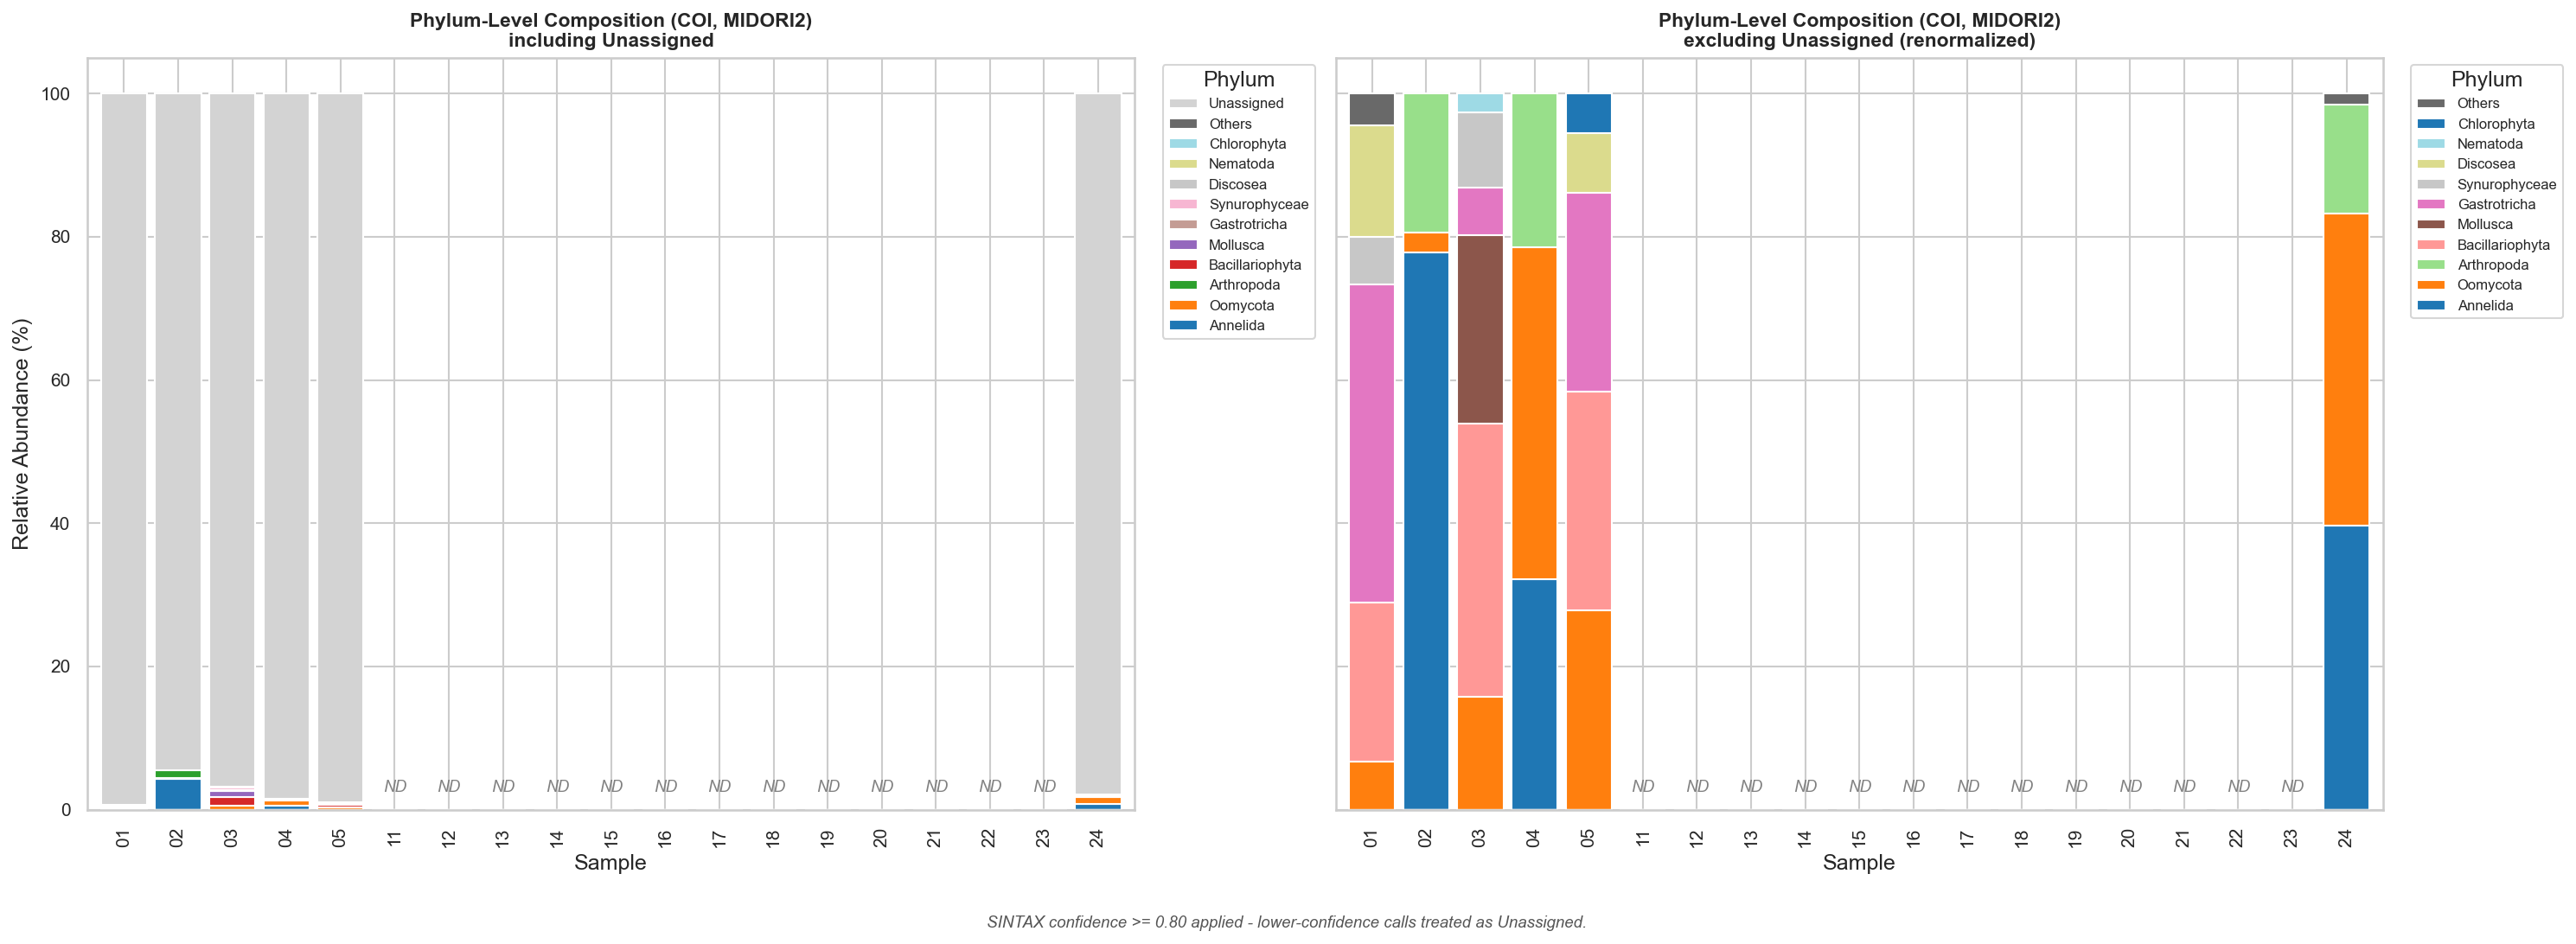

In [19]:
stacked_bar_compare(df_coi, 'Phylum', prefix_coi, 'COI', sample_cols_coi, top_n=10)

## B.1b Class-Level Breakdown (COI, MIDORI2)

[COI] Class: Unassigned = 97.8% of reads


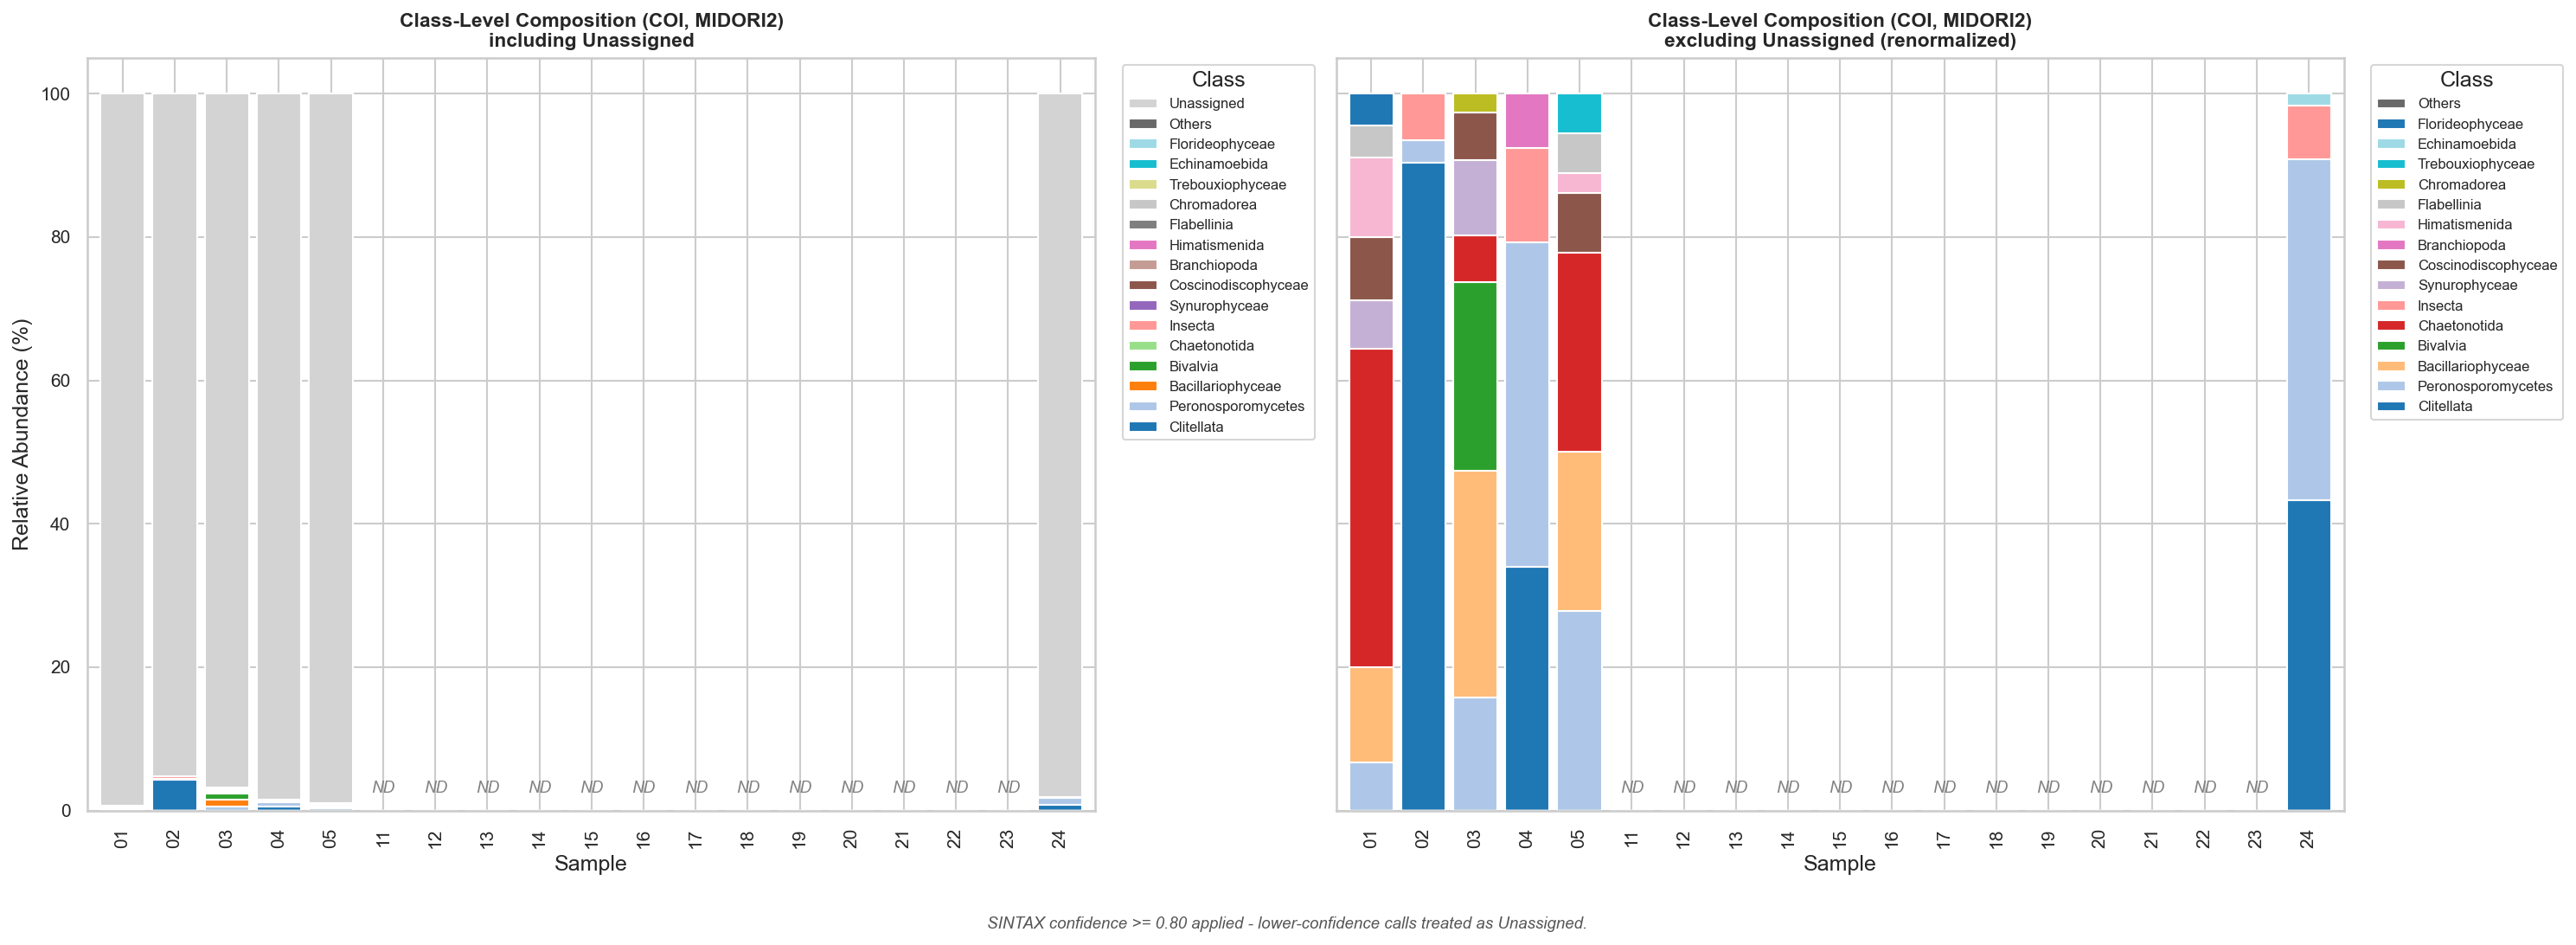

In [20]:
stacked_bar_compare(df_coi, 'Class', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.2 Order-Level Breakdown (COI)

[COI] Order: Unassigned = 98.0% of reads


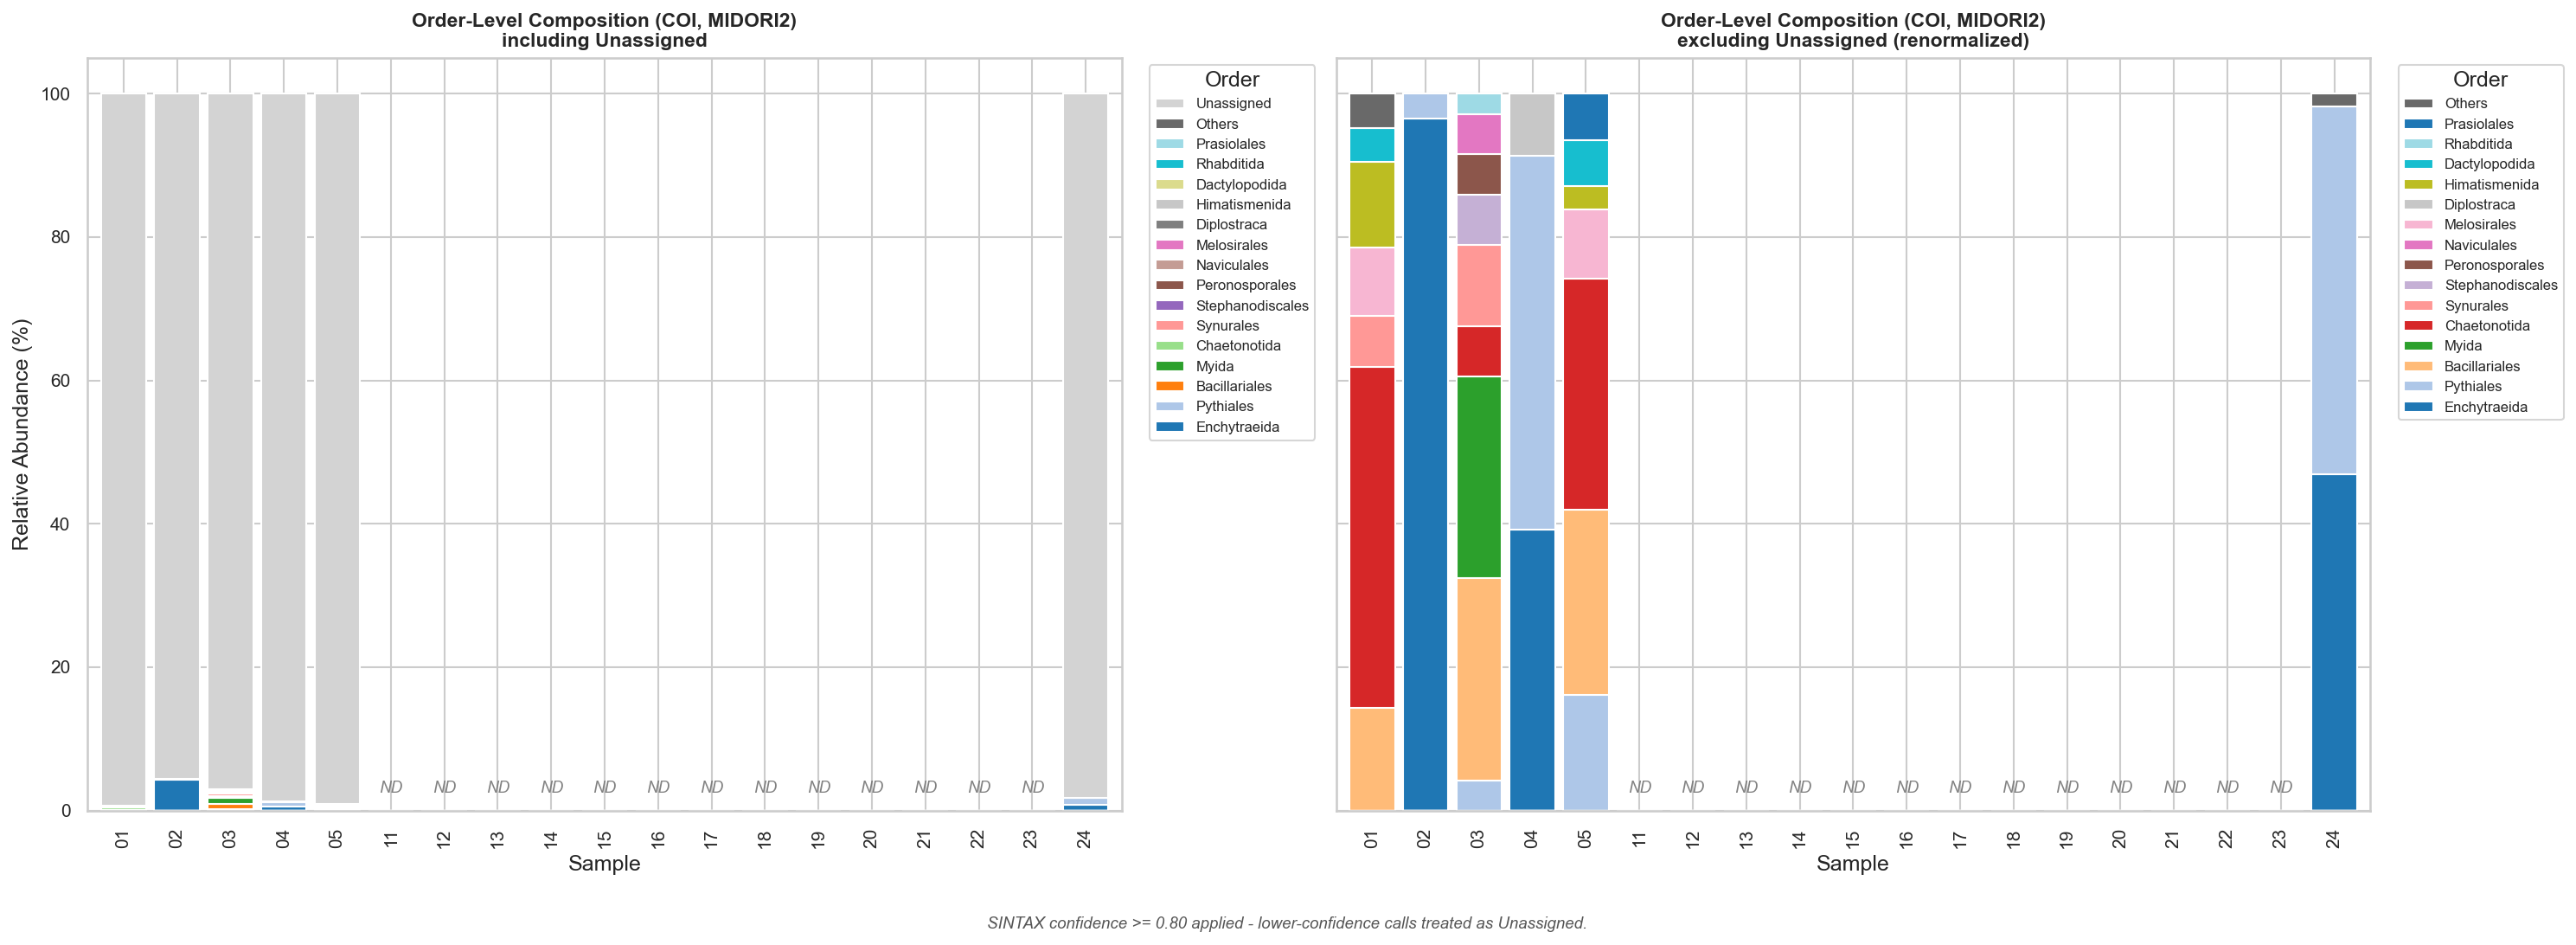

In [21]:
stacked_bar_compare(df_coi, 'Order', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.3 Genus-Level Top 20 (COI)

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:622: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


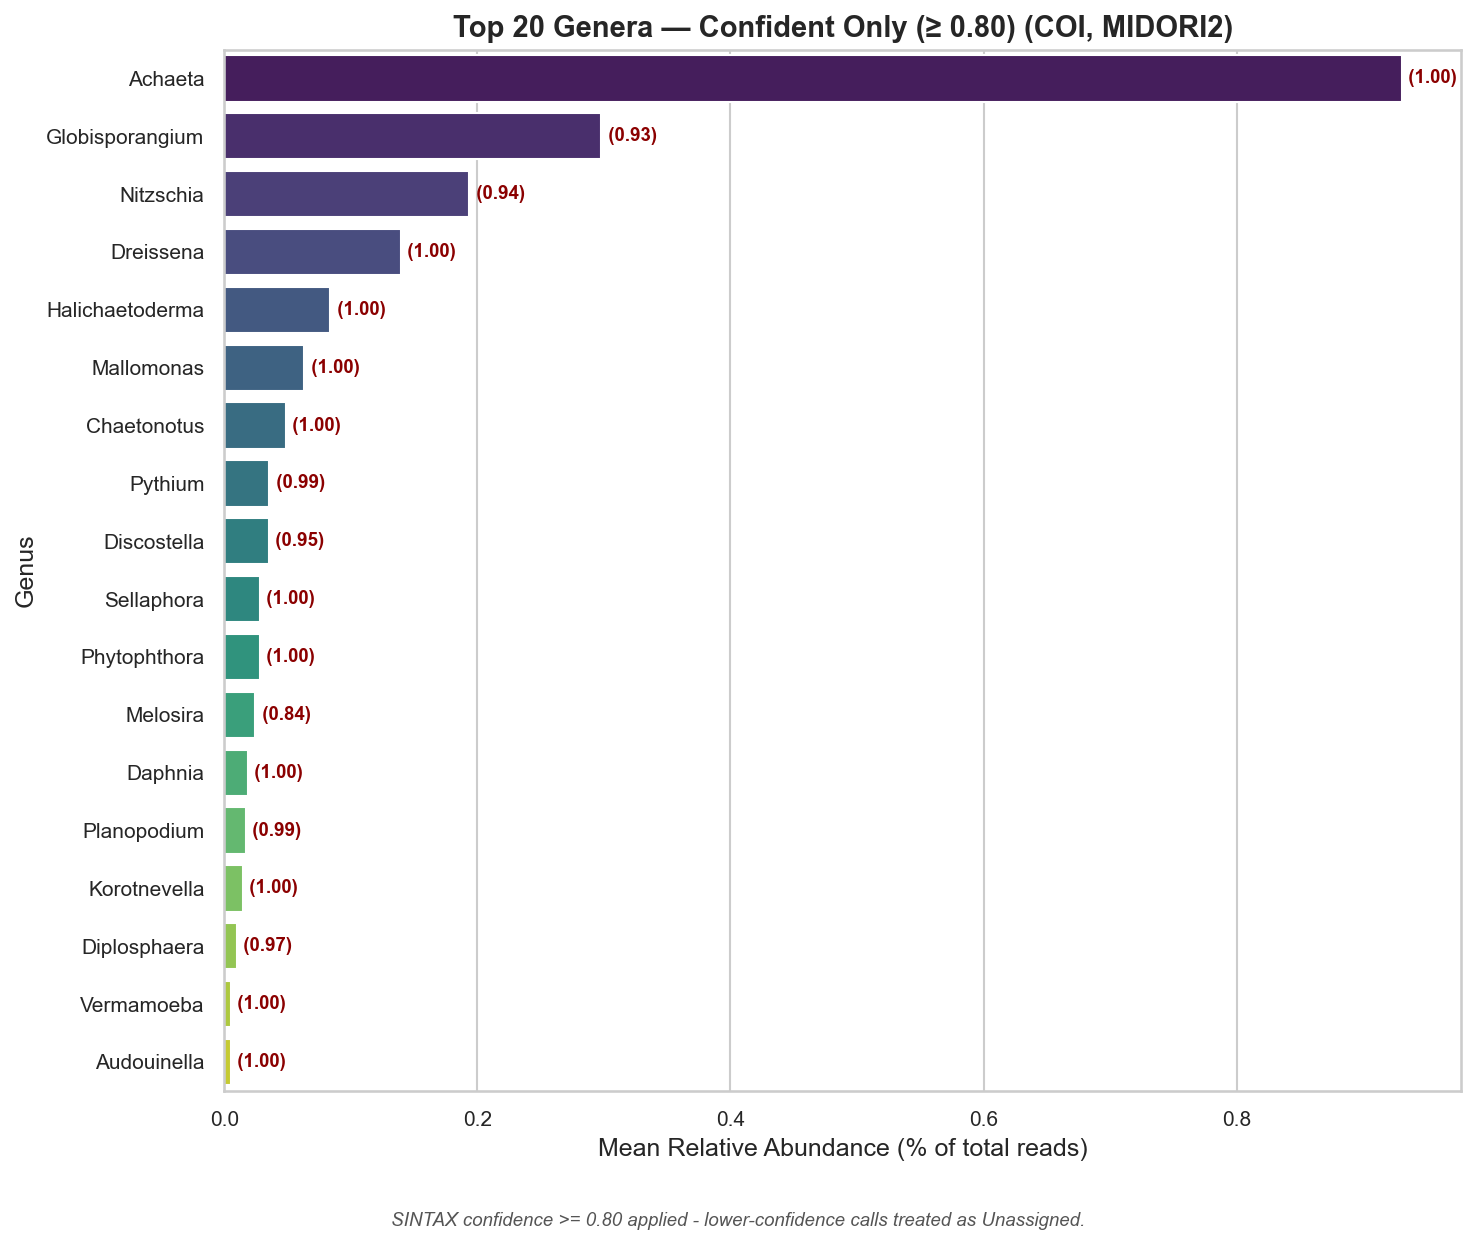

In [22]:
plot_top_genera_confident(df_coi, prefix_coi, 'COI', sample_cols_coi)

### Top 20 Genera by Abundance — All Confidences (COI)

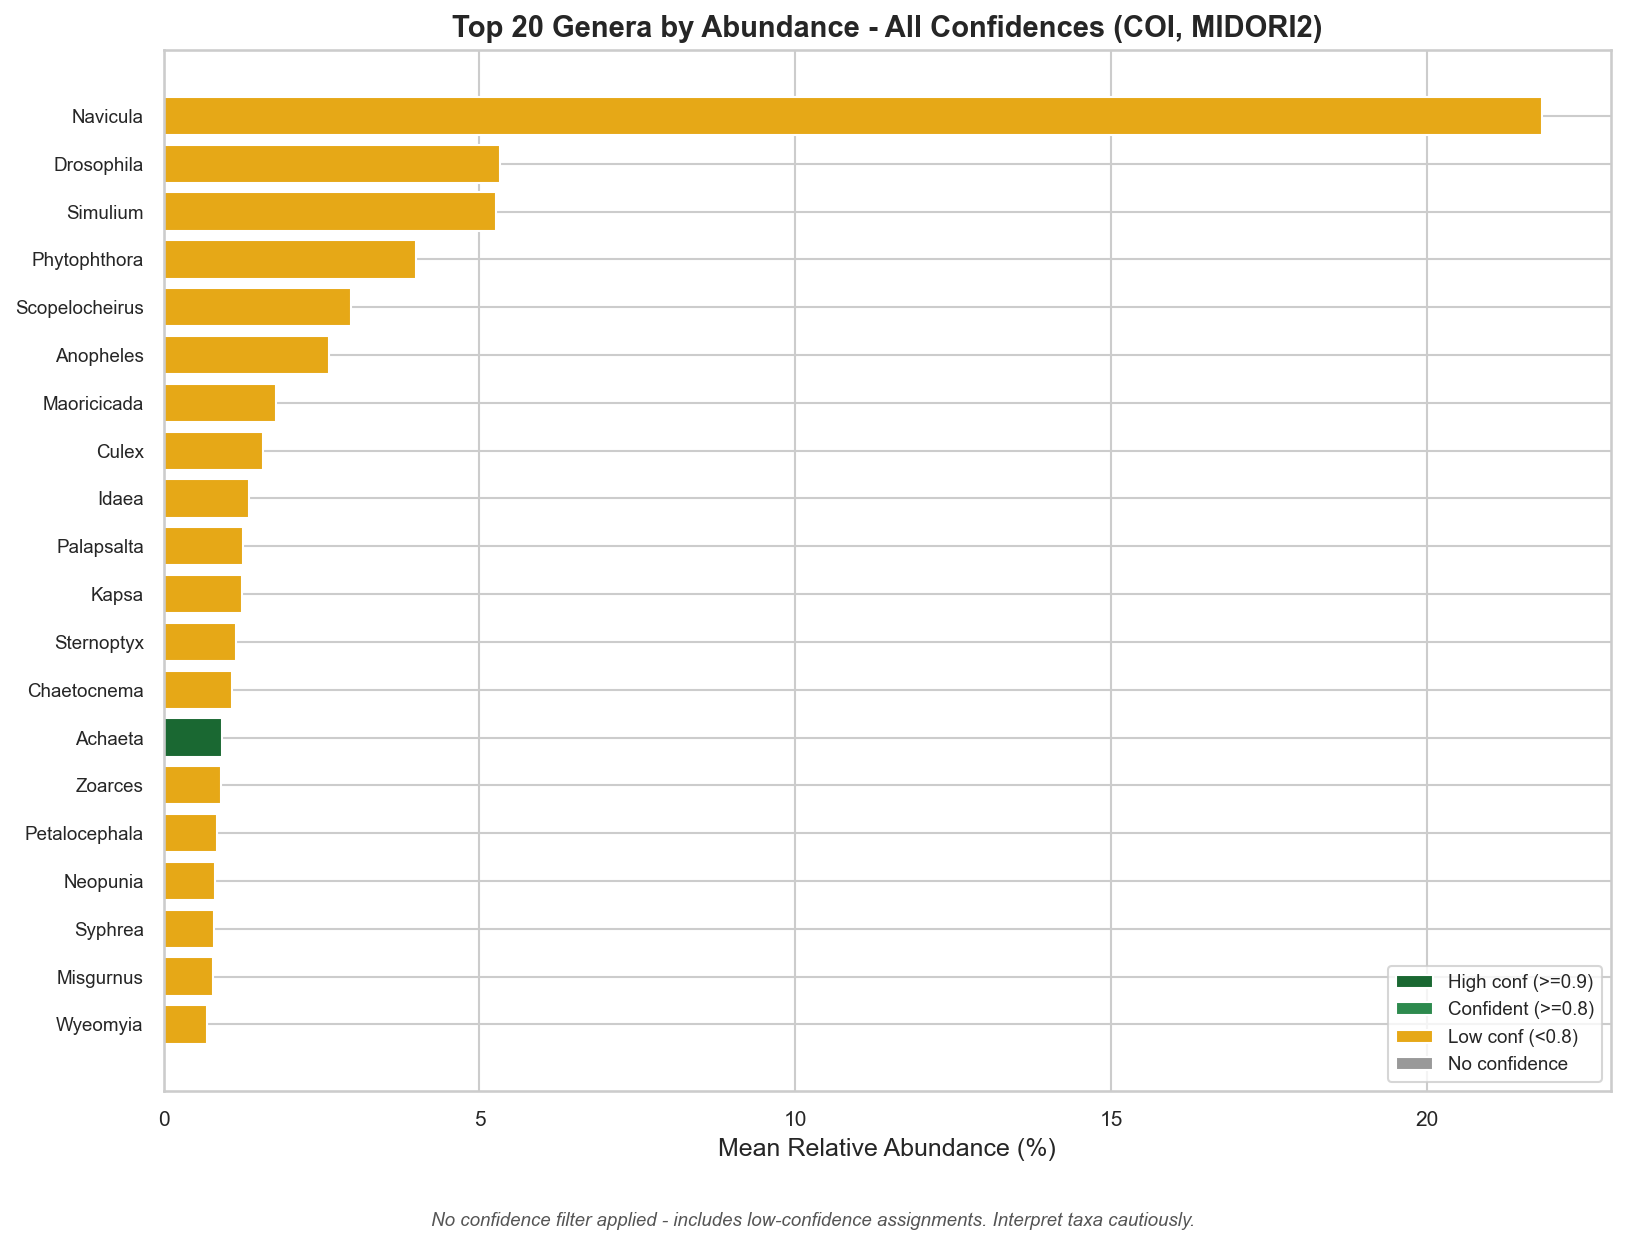

In [23]:
plot_top_genera_all(df_coi, prefix_coi, 'COI', sample_cols_coi)

## B.3b Top 20 Eukaryotic Genera (COI, MIDORI2)

Eukaryota filter: 1500/1503 OTUs (99.8%)


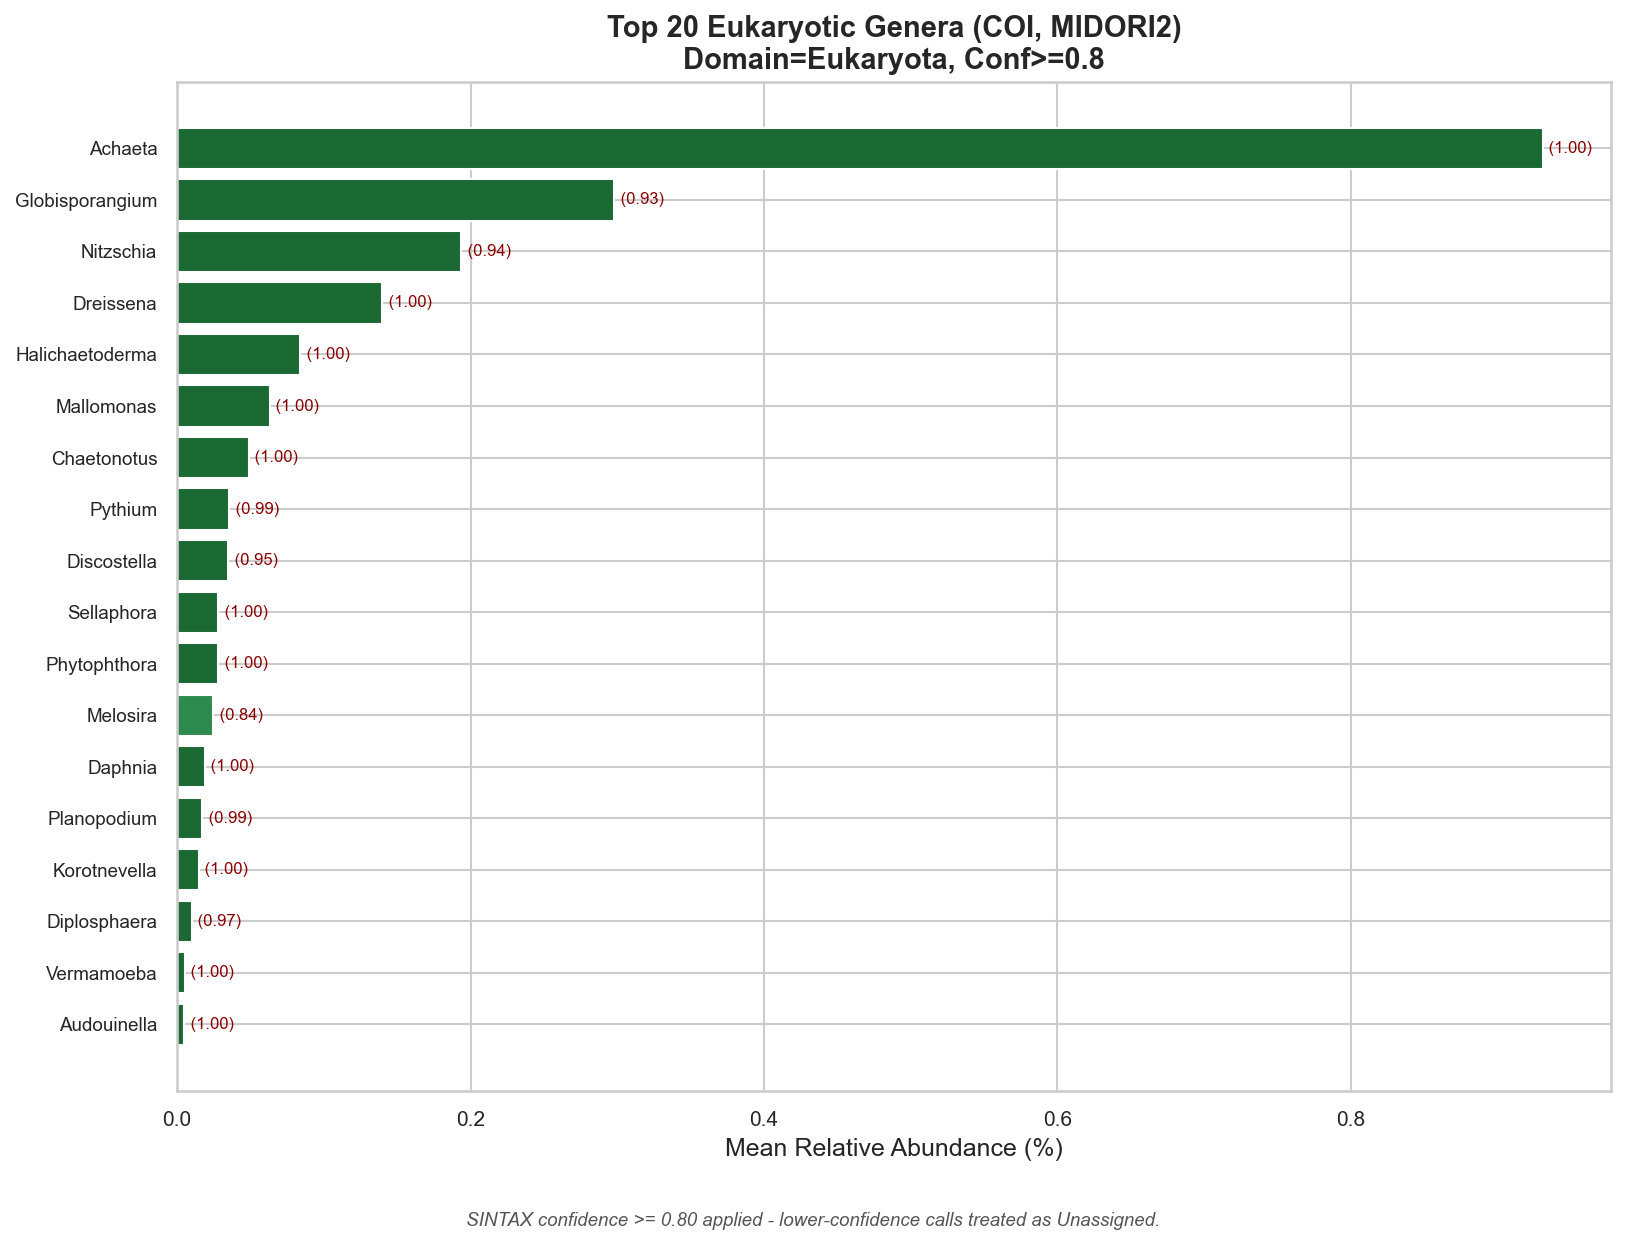

In [24]:
plot_eukaryotic_genera(df_coi, prefix_coi, 'COI', sample_cols_coi)

## BLAST Validation — COI

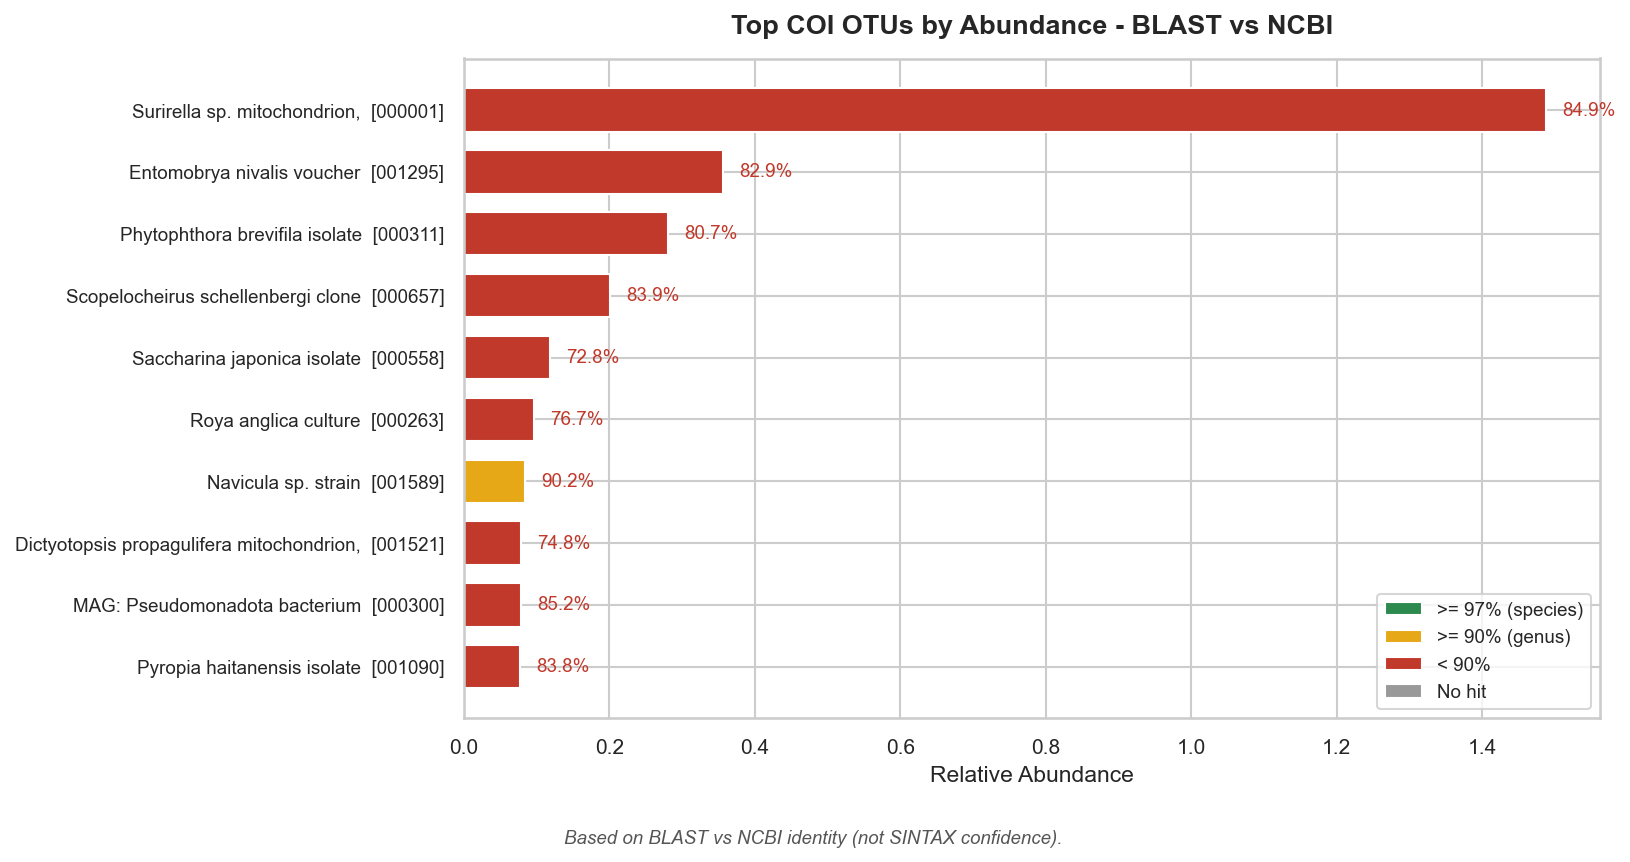

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:877: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),Phylum,Class,Order,Family,Genus,Species
OTU_COI_000001,1.4883,"Surirella sp. mitochondrion,",84.9%,Bacillariophyta (0.25),Bacillariophyceae (0.18),Naviculales (0.08),Naviculaceae (0.04),Navicula (0.02),Navicula (0.02)
OTU_COI_001295,0.3559,Entomobrya nivalis voucher,82.9%,Arthropoda (0.76),Insecta (0.32),Diptera (0.09),Simuliidae (0.02),Simulium (0.02),Simulium (0.02)
OTU_COI_000311,0.2804,Phytophthora brevifila isolate,80.7%,Oomycota (0.28),Peronosporomycetes (0.27),Peronosporales (0.21),Peronosporaceae (0.21),Phytophthora (0.15),Phytophthora (0.15)
OTU_COI_000657,0.2012,Scopelocheirus schellenbergi clone,83.9%,Arthropoda (0.44),Malacostraca (0.30),Amphipoda (0.29),Lysianassidae (0.29),Scopelocheirus (0.28),Scopelocheirus (0.28)
OTU_COI_000558,0.1183,Saccharina japonica isolate,72.8%,Arthropoda (0.41),Insecta (0.26),Diptera (0.10),Drosophilidae (0.03),Drosophila (0.02),Drosophila (0.02)
OTU_COI_000263,0.0964,Roya anglica culture,76.7%,Arthropoda (0.20),Insecta (0.15),Hemiptera (0.04),Cicadidae (0.02),Maoricicada (0.01),Maoricicada (0.01)
OTU_COI_001589,0.0835,Navicula sp. strain,90.2%,Bacillariophyta (0.51),Bacillariophyceae (0.48),Naviculales (0.43),Naviculaceae (0.40),Navicula (0.39),Navicula (0.39)
OTU_COI_001521,0.0787,"Dictyotopsis propagulifera mitochondrion,",74.8%,Arthropoda (0.44),Insecta (0.32),Hemiptera (0.10),Cicadellidae (0.05),Kapsa (0.01),Kapsa (0.01)
OTU_COI_000300,0.0778,MAG: Pseudomonadota bacterium,85.2%,Chordata (0.18),Actinopteri (0.07),Stomiiformes (0.02),Sternoptychidae (0.02),Sternoptyx (0.02),Sternoptyx (0.02)
OTU_COI_001090,0.0774,Pyropia haitanensis isolate,83.8%,Arthropoda (0.43),Insecta (0.39),Lepidoptera (0.11),Geometridae (0.04),Idaea (0.01),Idaea (0.01)


In [25]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), 'COI', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), df_coi_raw, prefix_coi, 'COI')

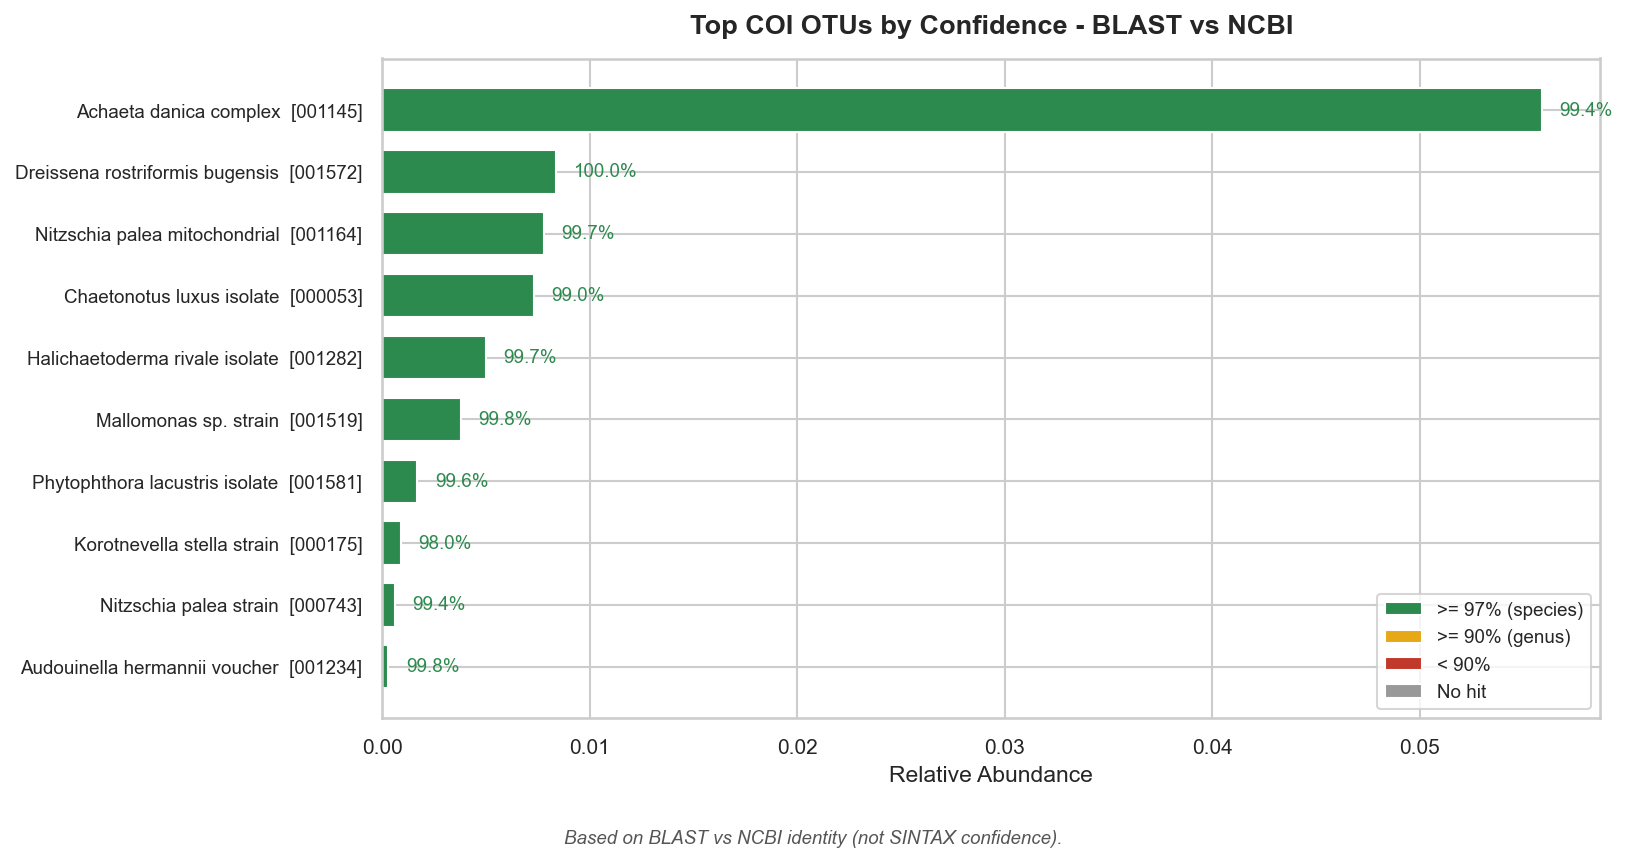

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:877: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_id, subset=['Identity (%)'])


OTU,Abundance,BLAST Top Hit,Identity (%),Phylum,Class,Order,Family,Genus,Species
OTU_COI_001519,0.0038,Mallomonas sp. strain,99.8%,Synurophyceae (1.00),Synurophyceae (1.00),Synurales (1.00),Mallomonadaceae (1.00),Mallomonas (1.00),Mallomonas (1.00)
OTU_COI_001282,0.0050,Halichaetoderma rivale isolate,99.7%,Gastrotricha (1.00),Chaetonotida (1.00),Chaetonotida (1.00),Chaetonotidae (1.00),Halichaetoderma (1.00),Halichaetoderma (1.00)
OTU_COI_001581,0.0017,Phytophthora lacustris isolate,99.6%,Oomycota (1.00),Peronosporomycetes (1.00),Peronosporales (1.00),Peronosporaceae (1.00),Phytophthora (1.00),Phytophthora (1.00)
OTU_COI_001164,0.0078,Nitzschia palea mitochondrial,99.7%,Bacillariophyta (1.00),Bacillariophyceae (1.00),Bacillariales (1.00),Bacillariaceae (1.00),Nitzschia (1.00),Nitzschia (1.00)
OTU_COI_000743,0.0006,Nitzschia palea strain,99.4%,Bacillariophyta (1.00),Bacillariophyceae (1.00),Bacillariales (1.00),Bacillariaceae (1.00),Nitzschia (1.00),Nitzschia (1.00)
OTU_COI_001572,0.0084,Dreissena rostriformis bugensis,100.0%,Mollusca (1.00),Bivalvia (1.00),Myida (1.00),Dreissenidae (1.00),Dreissena (1.00),Dreissena (1.00)
OTU_COI_000175,0.0009,Korotnevella stella strain,98.0%,Discosea (1.00),Flabellinia (1.00),Dactylopodida (1.00),Paramoebidae (1.00),Korotnevella (1.00),Korotnevella (1.00)
OTU_COI_001145,0.0559,Achaeta danica complex,99.4%,Annelida (1.00),Clitellata (1.00),Enchytraeida (1.00),Enchytraeidae (1.00),Achaeta (1.00),Achaeta (1.00)
OTU_COI_000053,0.0073,Chaetonotus luxus isolate,99.0%,Gastrotricha (1.00),Chaetonotida (1.00),Chaetonotida (1.00),Chaetonotidae (1.00),Chaetonotus (1.00),Chaetonotus (1.00)
OTU_COI_001234,0.0003,Audouinella hermannii voucher,99.8%,Rhodophyta (1.00),Florideophyceae (1.00),Acrochaetiales (1.00),Acrochaetiaceae (1.00),Audouinella (1.00),Audouinella (1.00)


In [26]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), 'COI', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), df_coi_raw, prefix_coi, 'COI')